# 14 — Results: Figures and Statistics (RQ1–RQ3)

**Pipeline step:** Section 4 of the paper (Results) — this is the notebook that produces the paper's actual figures and reported statistics, organized by research question.

**Structure:**
1. **RQ1** — characteristics of each macrotopic (video counts, toxicity distributions, pairwise significance).
2. **RQ2** — diffusion of political vs. non-political videos on Telegram (correlations, cumulative/CCDF diffusion curves).
3. **RQ3** — temporal analysis (weekly toxicity, video counts, channel growth).

**Input:**
- `../data/not_27.parquet` — Enriched dataset from `13_Preparing_Results_Data.ipynb` (`macrotopics_pred.csv` + `lifetime`/`send_count`/`transfer_time`/`first_appearance`).

**Output:** figure files (PNG), saved to two different locations — see the note below.

> ⚠️ **Output path inconsistency:** most of RQ1/RQ2 (and the first few RQ3 plots) save to `{OUTPUT_DIR}/rqN/...` where `OUTPUT_DIR = "../reports/Figures"` (set in the cell that also configures the RQ1 plot style). From partway through RQ3 onward (the video-count and channel-count plots), several `savefig` calls switch to a hardcoded relative path `gráficos/...` instead — a different folder, not under `reports/Figures/`, and not guaranteed to exist when the notebook runs from a different working directory. Left as-is (no code changes), but worth fixing before publishing, since it means the RQ3 figures don't end up alongside the RQ1/RQ2 ones.

Loads the enriched dataset produced by `13_Preparing_Results_Data.ipynb`:

In [1]:
import pandas as pd 

df_all = pd.read_parquet("../data/not_27.parquet")
df_all

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,...,perspective_obscene,perspective_toxicity,perspective_identity_attack,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count,transfer_time,first_appearance
0,jEKzQV5oajY,travel migrant scrap minute,Joe Marsh,2024-04-10T15:05:37Z,1057.0,152.0,32.0,"[{'date': '2024-04-14', 'folder': 'channel_155...",0.000659,0.000117,...,0.138744,0.360951,0.367026,0.038566,Others,0.000000,1.0,1,3.0,2024-04-14
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'date': '2024-01-06', 'folder': 'channel_146...",0.295000,0.001137,...,0.008414,0.123468,0.049762,0.029415,Religion,0.000000,1.0,1,79.0,2024-01-06
2,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'date': '2024-02-22', 'folder': 'channel_123...",0.001735,0.000102,...,0.003292,0.229804,0.062040,0.033386,Others,0.021935,1.0,4,0.0,2024-02-22
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,"[{'date': '2024-10-27', 'folder': 'channel_157...",0.002710,0.000104,...,0.001093,0.075294,0.017666,0.022509,Religion,0.005000,2.0,5,0.0,2024-10-27
4,AKU0RokegSo,angeles rain studio city evacuate mudslide atm...,FOX 11 Los Angeles,2024-02-06T01:45:29Z,60863.0,406.0,152.0,"[{'date': '2024-02-06', 'folder': 'channel_143...",0.001515,0.000100,...,0.002368,0.111507,0.019375,0.028207,Environment,0.000000,2.0,2,0.0,2024-02-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673582,ABpufr8inCY,eruption kilauea volcano earthquake activity i...,TheEarthMaster,2024-09-17T19:15:25Z,10563.0,712.0,38.0,"[{'date': '2024-09-17', 'folder': 'channel_117...",0.003324,0.000098,...,0.001717,0.004477,0.002119,0.008324,Environment,0.000000,1.0,1,0.0,2024-09-17
673583,5VWWCeGrr-w,eslteacher funny kidsvideo play easy makeup le...,Game fanny,2024-05-08T22:00:03Z,2.0,0.0,0.0,"[{'date': '2024-05-09', 'folder': 'channel_139...",0.004620,0.000084,...,0.005302,0.011395,0.207752,0.010628,Others,0.091652,1.0,1,0.0,2024-05-09
673584,RxbPFQp0SHs,unbelievable ending watch play bgmi thank watc...,𝐒∆𝐈𝐘𝐀𝐍 • 127K views • 6 hours ago,2023-12-29T23:30:11Z,82.0,4.0,0.0,"[{'date': '2023-12-30', 'folder': 'channel_121...",0.023877,0.000158,...,0.006375,0.063423,0.010581,0.012907,Others,0.000000,1.0,2,0.0,2023-12-30
673585,GEhEUy85PsY,meet balkan,Icariaball,2021-04-22T16:25:46Z,7617763.0,210152.0,14042.0,"[{'date': '2023-12-26', 'folder': 'channel_175...",0.007485,0.000123,...,0.008087,0.016662,0.045911,0.020955,Others,0.026730,1.0,1,977.0,2023-12-26


Standardizes a couple of macro-topic labels to shorter display names (`"Crime, Security and Justice"` → `"Crime, S. and J."`, `"American Politics"` → `"US Politics"`), and drops rows with no toxicity score:

In [2]:
df_all['macrotopic_pred'] = ['Crime, S. and J.' if topic == 'Crime, Security and Justice' else topic for topic in df_all['macrotopic_pred']]
df_all['macrotopic_pred'] = ['US Politics' if topic == 'American Politics' else topic for topic in df_all['macrotopic_pred']]

df_all = df_all[df_all['perspective_toxicity'].notna()]
print(f"Número de linhas após filtrar valores nulos em 'perspective_toxicity': {len(df_all)}")

Número de linhas após filtrar valores nulos em 'perspective_toxicity': 673586


Toxicity metric columns used throughout the notebook (all six Perspective API dimensions):

In [3]:
tox_cols = [
    'perspective_toxicity',
    'perspective_severe_toxicity',
    'perspective_insult',
    'perspective_obscene',
    'perspective_threat',
    'perspective_identity_attack'
]

Defines the political/non-political topic split, a two-color `palette_map` for that split, the list of macro-topics kept for analysis (`interest` — excludes `Others`), and `macro_colors` — a per-topic color palette (with an earlier, brighter version left commented out above it). Filters `df` down to just the topics of interest:

In [4]:
politics = ['US Politics', 'War', 'Foreign Policy', 'Crime, S. and J.']
non_politics = ['Health', 'Hobbies', 'Religion', 'Entertainment', 'Technology', 'Environment']

palette_map = {}

for topic in non_politics:
    palette_map[topic] = "#577a8b"  

for topic in politics:
    palette_map[topic] = "#f4a04c"   
interest = [
    'War',
    'US Politics',
    'Foreign Policy',
    'Crime, S. and J.',
    'Health',
    'Religion',
    'Hobbies'
    ,"Technology"
    ,"Environment"
    ,"Entertainment"
]
"""
macro_colors = {
    "US Politics":             "#6AF5FF",
    "Foreign Policy":              "#76FF7F",
    "Crime, S. and J.":     "#FF66CC",
    "Health":                  "#522222",
    "Hobbies":       "#DA0000",
    "Religion":                       "#962EAA",
    "War":                         "#5C5C61"
    , "Technology": "#890082"
    , "Environment": "#008000"
    , "Entertainment": "#FFD700"
}
"""
macro_colors = {
    "US Politics":             "#5FD6DE",  # era #6AF5FF
    "Foreign Policy":               "#4CBD71",  # era #76FF7F
    "Crime, S. and J.":   "#F07AA8",  # era #FF66CC
    "Health":                       "#6A3A3A",  # era #522222
    "Hobbies":                      "#C43A3A",  # era #DA0000
    "Religion":                     "#8E5FA6",  # era #962EAA
    "War":                          "#6B6F78"   # era #5C5C61
    , "Technology": "#7A0078"      # versão mais suave do #890082
    , "Environment": "#2F8F4E"     # versão mais suave do #008000
    , "Entertainment": "#E6C24A"   # versão mais suave do #FFD700
}

df = df_all[df_all["macrotopic_pred"].isin(interest)]
len(df)

427959

Explodes `occurrences` into one row per Telegram send event, flattening the nested fields (`date`, `folder`/channel, etc.) into columns — this `df_complete` is the row-per-occurrence table used by most of the diffusion and temporal analysis below:

In [5]:
df_exploded = df.explode('occurrences').reset_index(drop=True)
df_normalized = pd.json_normalize(df_exploded['occurrences'])
df_complete = pd.concat([
    df_exploded.drop(columns=['occurrences']), 
    df_normalized
], axis=1)
display(df_complete.head())

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,toxicity,severe_toxicity,obscene,...,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count,transfer_time,first_appearance,date,folder,id
0,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,0.29500,0.001137,0.003694,...,0.029415,Religion,0.000,1.0,1,79.0,2024-01-06,2024-01-06,channel_1466271872,60799.0
1,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,2024-10-27,channel_1571505334,449843.0
2,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,2024-10-28,channel_1366456452,205296.0
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,2024-10-27,channel_2091154967,123625.0
4,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,2024-10-27,channel_1548295614,462353.0


___
## **RQ1 Analisando características de cada tópico**

Global plot styling for the RQ1/RQ2 figures (font, colors, weights) and `OUTPUT_DIR` where figures are saved — see the path-inconsistency note at the top of this notebook:

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sns.set_theme(
    style="white",
    font="Liberation Sans"
)

plt.rcParams.update({
    'font.family': 'Liberation Sans',  
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'figure.titlesize': 22,
    'text.color': "#3F3F3FD8",
    'axes.labelcolor': "#3F3F3FD8",
    'xtick.color': "#3F3F3FD8",
    'ytick.color': "#3F3F3FD8",
    'font.weight': 700, 
    'axes.labelweight': 700,
    'axes.titleweight': 700,
})

format = 'png' 
OUTPUT_DIR = "../reports/Figures"

*(Section marker left by the author, kept as-is — likely a personal note-to-self while iterating on this figure, not meant as a reader-facing heading.)*

#### NOV

**Figure — number of videos per macrotopic.** Horizontal bar chart, political topics vs. non-political (hatched) topics, sorted, with a k-formatted x-axis. Saves `rq1/num_videos_per_macrotopic_horizontal.png`:

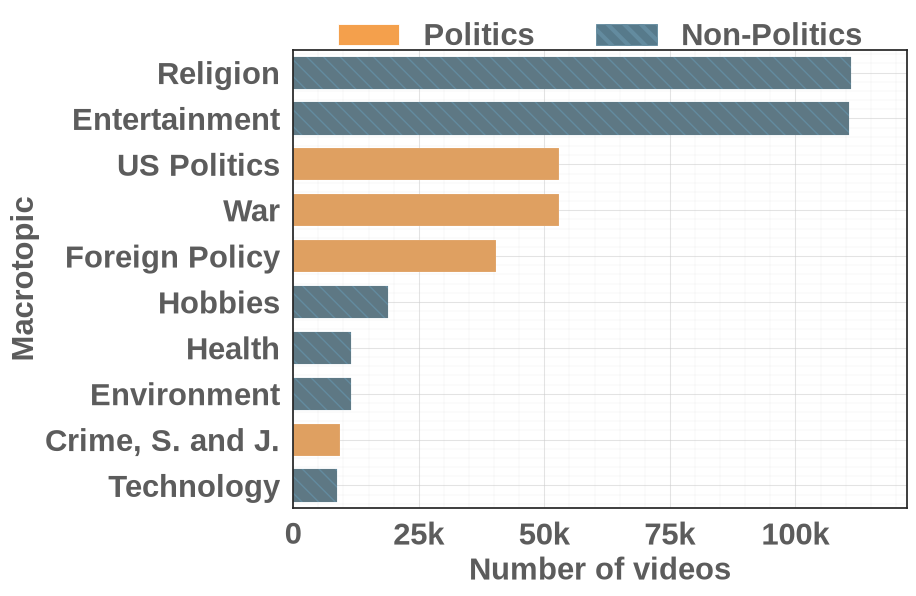

In [8]:
topic_count = df_all['macrotopic_pred'].value_counts().reset_index()
topic_count = topic_count[topic_count['macrotopic_pred'] != 'Others']

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    y='macrotopic_pred',     
    x='count',             
    hue='macrotopic_pred',
    data=topic_count,
    palette=palette_map,
    width=0.7,
    legend=False
)

for patch, topic in zip(ax.patches, topic_count['macrotopic_pred']):
    if topic in politics:
        #patch.set_hatch('//')      # 8 barras
        #patch.set_edgecolor("#f0b77e")
        i=0
    else:
        patch.set_hatch('\\\\')  # 8 barras invertidas
        patch.set_edgecolor('#638b9f')
    #patch.set_edgecolor("#353535")
    patch.set_linewidth(0.1)

mpl.rcParams['hatch.linewidth'] = 3

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

plt.xlabel('Number of videos')
plt.ylabel('Macrotopic')

plt.yticks()
plt.xticks()

plt.xlim(0, topic_count['count'].max() * 1.1)

legend_elements = [
    Patch(facecolor=palette_map['War'],
          #edgecolor='#f0b77e',
          #hatch='//',
          label='Politics',
          linewidth=0.6),

    Patch(facecolor=palette_map['Religion'],
          edgecolor='#638b9f',
          hatch='\\\\',
          label='Non-Politics',
          linewidth=0.6)
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

from matplotlib.ticker import FuncFormatter

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}')
)

plt.savefig(f"{OUTPUT_DIR}/rq1/num_videos_per_macrotopic_horizontal.{format}", format=format, bbox_inches='tight')
plt.show()

### boxplot

**Figure — toxicity distribution per macrotopic.** Boxplot of `perspective_toxicity` by macrotopic, ordered by median, with the same politics/non-politics hatching. Saves `rq1/boxplot_toxicity_horizontal.png`:

/tmp/ipykernel_10686/2236512651.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


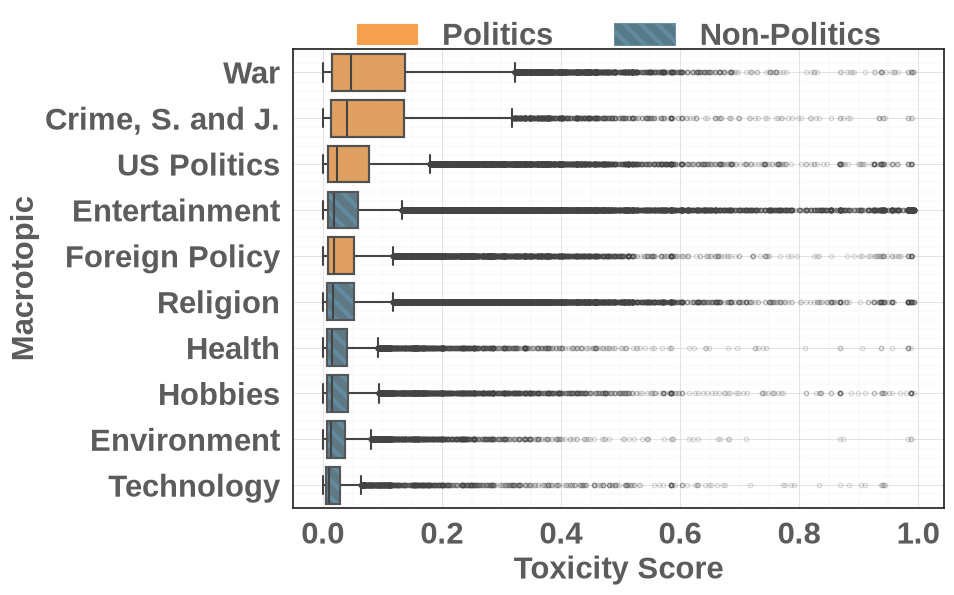

In [9]:
ordem_decrescente = (
    df.groupby('macrotopic_pred')['perspective_toxicity']
      .median()
      .sort_values(ascending=False)
      .index
)

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    x='perspective_toxicity',
    y='macrotopic_pred',
    data=df,
    palette=palette_map,
    order=ordem_decrescente,
    linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.2)
)

for patch, topic in zip(ax.patches, ordem_decrescente):
    if topic in politics:
        #patch.set_hatch('//')      
        #patch.set_edgecolor("#f0b77e")
        i=0
    else:
        patch.set_hatch('\\\\')  
        patch.set_edgecolor('#638b9f')
    patch.set_linewidth(1.5)
    patch.set_zorder(2)

    # borda cinza por cima
    bbox = patch.get_path().get_extents()
    rect = plt.Rectangle(
        (bbox.x0, bbox.y0),
        bbox.x1 - bbox.x0,
        bbox.y1 - bbox.y0,
        linewidth=1.5,
        edgecolor="#525252E6",
        facecolor='none',
        transform=ax.transData,
        zorder=3
    )
    ax.add_patch(rect)


mpl.rcParams['hatch.linewidth'] = 3

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

# rótulos
plt.xlabel('Toxicity Score')
plt.ylabel('Macrotopic')
plt.xticks()
plt.yticks()

legend_elements = [
    Patch(facecolor=palette_map['War'],
          #edgecolor='#f0b77e',
          #hatch='//',
          label='Politics',
          linewidth=0.6),

    Patch(facecolor=palette_map['Religion'],
          edgecolor='#638b9f',
          hatch='\\\\',
          label='Non-Politics',
          linewidth=0.6)
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"{OUTPUT_DIR}/rq1/boxplot_toxicity_horizontal.{format}", format=format, bbox_inches='tight')
plt.show()

Descriptive statistics (`count`/`mean`/`std`/`min`/quartiles/`max`) of toxicity per macrotopic, as a table:

In [10]:
stats = df.groupby('macrotopic_pred')['perspective_toxicity'].describe()
tabela_final = stats.T
display(tabela_final.round(3))

macrotopic_pred,"Crime, S. and J.",Entertainment,Environment,Foreign Policy,Health,Hobbies,Religion,Technology,US Politics,War
count,9341.000,110639.000,11500.000,40410.000,11522.000,18913.000,111071.000,8719.000,52998.000,52846.000
mean,0.100,0.066,0.037,0.052,0.042,0.046,0.055,0.036,0.068,0.098
std,0.130,0.126,0.064,0.089,0.076,0.089,0.097,0.079,0.106,0.118
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.014,0.009,0.007,0.008,0.007,0.007,0.008,0.005,0.009,0.015
50%,0.041,0.019,0.014,0.019,0.015,0.015,0.017,0.011,0.023,0.047
75%,0.136,0.059,0.037,0.052,0.041,0.042,0.052,0.029,0.078,0.138
max,0.989,0.994,0.988,0.989,0.988,0.994,0.994,0.945,0.989,0.994


### Matriz

**Pairwise Mann-Whitney U tests** between every pair of macrotopics' toxicity distributions (one-sided: "is topic L more toxic than topic C"), with Bonferroni correction (`0.05 / 81` — 81 = number of ordered pairs among the 9 topics). Builds a binary significance matrix:

In [11]:
from scipy.stats import mannwhitneyu
import numpy as np

toxicity_per_topic={}


for idx,df_group in df.groupby('macrotopic_pred'):
    toxicity_per_topic[idx]=df_group['perspective_toxicity']

comparison_per_topic={}
mannwithney_test_pairwise=np.zeros((len(toxicity_per_topic),len(toxicity_per_topic)))
ordered_topics=sorted(politics)+sorted(non_politics)
for i,idx1 in enumerate(ordered_topics):
    for j,idx2 in enumerate(ordered_topics):
        if idx1==idx2:
            continue
        test=mannwhitneyu(toxicity_per_topic[idx1].to_list(),toxicity_per_topic[idx2].to_list(),alternative='greater').pvalue
        if test<0.05/81: #Bonferroni Correction: every topic is compared with all the others:  
            print(idx1,idx2,test)
            mannwithney_test_pairwise[i,j]=1
mannwithney_test_pairwise=pd.DataFrame(mannwithney_test_pairwise,index=ordered_topics,columns=ordered_topics)
mannwithney_test_pairwise

Crime, S. and J. Foreign Policy 0.0
Crime, S. and J. US Politics 5.6937223312494755e-176
Crime, S. and J. Entertainment 0.0
Crime, S. and J. Environment 0.0
Crime, S. and J. Health 0.0
Crime, S. and J. Hobbies 0.0
Crime, S. and J. Religion 0.0
Crime, S. and J. Technology 0.0
Foreign Policy Environment 4.420228230774271e-60
Foreign Policy Health 1.7671294933674777e-46
Foreign Policy Hobbies 2.7919442348323967e-49
Foreign Policy Religion 1.4192620513589319e-12
Foreign Policy Technology 4.291561217362917e-178
US Politics Foreign Policy 1.1344066349051939e-131
US Politics Entertainment 2.965974402759845e-84
US Politics Environment 4.094143767634726e-226
US Politics Health 5.513530653609741e-193
US Politics Hobbies 4.3893841067424745e-248
US Politics Religion 2.0581602880892954e-295
US Politics Technology 0.0
War Crime, S. and J. 0.00012825247506006082
War Foreign Policy 0.0
War US Politics 0.0
War Entertainment 0.0
War Environment 0.0
War Health 0.0
War Hobbies 0.0
War Religion 0.0
War Tec

,"Crime, S. and J.",Foreign Policy,US Politics,War,Entertainment,Environment,Health,Hobbies,Religion,Technology
"Crime, S. and J.",0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
Foreign Policy,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
US Politics,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
War,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
Entertainment,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
Environment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Health,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Hobbies,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Religion,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
Technology,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Manually fixes the display order of topics for the matrix plot below (the automatic sort-by-significance-count is computed but then overridden by a hardcoded list):

In [12]:
ordered=mannwithney_test_pairwise.sum(axis=1).sort_values(ascending=False).index
ordered=['War', 'Crime, S. and J.', 'US Politics', 'Foreign Policy','Entertainment', 'Religion', 'Hobbies', 'Environment','Health', 'Technology']
ordered_inv = ordered[::-1]

**Figure — pairwise significance "bubble matrix".** Filled circle = topic L is significantly more toxic than topic C; open circle = not significant. Saves `rq1/bubble_mannwhitney.png`:

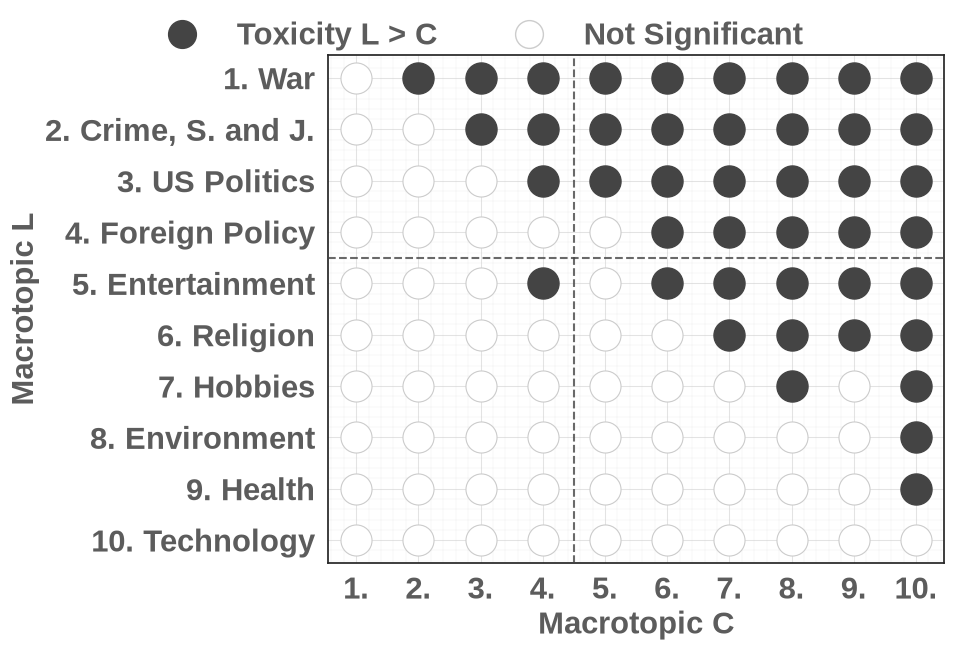

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

data = mannwithney_test_pairwise.loc[ordered, ordered]

for i, row in enumerate(ordered):
    for j, col in enumerate(ordered):
        if data.loc[row, col] == 1:
            ax.scatter(j, i, s=500, color='#444444', zorder=3)
        else:
            ax.scatter(j, i, s=500, color='white', edgecolors='#cccccc', linewidth=0.8, zorder=2)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#444444',
           markeredgecolor='#444444', markersize=20, label='Toxicity L > C'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor='#cccccc', markersize=20, label='Not Significant')
]

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ax.set_xticks(range(len(ordered)))
ax.set_xticklabels([f"{i}." for i in range(1, len(ordered) + 1)], rotation=0)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([f"{i+1}. {name}" for i, name in enumerate(ordered)])
ax.invert_yaxis()
ax.set_ylabel("Macrotopic L")
ax.set_xlabel("Macrotopic C")

leg = fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.50, 0.97),
    ncol=2,
    frameon=False
)

ax.axhline(y=3.5, color='#444444', linestyle='--', linewidth=1.5, alpha=0.8, zorder=4)
ax.axvline(x=3.5, color='#444444', linestyle='--', linewidth=1.5, alpha=0.8, zorder=4)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(f"{OUTPUT_DIR}/rq1/bubble_mannwhitney.{format}", format=format, bbox_inches='tight')
plt.show()

___
## **RQ2 Analisando a Difusão de vídeos políticos pelo Telegram**

Redefines `df`/`df_complete` restricted to the `interest` topics — note `interest` is redefined here **without** Technology/Environment/Entertainment (commented out), narrowing RQ2's scope to the 7 "core" topics rather than all 9:

In [7]:
interest = ['War','US Politics','Foreign Policy','Crime, S. and J.','Health','Religion','Hobbies'
    #,"Technology","Environment","Entertainment"
    ]
df = df_all[df_all["macrotopic_pred"].isin(interest)]
df_complete = df_complete[df_complete["macrotopic_pred"].isin(interest)]

#### *Correlação de Spearman*

`spearman_by_topic` — Spearman correlation between a pivot column and each toxicity metric, computed separately per macrotopic:

In [8]:
from scipy.stats import spearmanr
def spearman_by_topic(df_topic, col_pivo ,cols):
    results = {}

    for col in cols:
        tmp = df_topic[[col_pivo, col]].dropna()

        rho, p = spearmanr(tmp[col_pivo], tmp[col])

        results[col] = {
            'spearman_rho': rho,
            'p_value': p,
            'n': len(tmp)
        }

    return results

`apply_spearman_correlation` — runs the function above across all macrotopics and reshapes the results into two pivot tables (correlation strength, and p-value):

In [9]:
def apply_spearman_correlation(df, col_pivo, cols):
    all_results = []

    for topic, df_topic in df.groupby('macrotopic_pred'):
        topic_results = spearman_by_topic(df_topic, col_pivo, cols)

        for metric, values in topic_results.items():
            all_results.append({
                'macrotopic_pred': topic,
                'metric': metric,
                'spearman_rho': values['spearman_rho'],
                'p_value': values['p_value'], 
                'n': values['n']
            })

    results_df = pd.DataFrame(all_results)

    # Tabela 1: Força da Correlação (Rho)
    pivot_rho = results_df.pivot(
        index='macrotopic_pred', columns='metric', values='spearman_rho'
    ).sort_index()
    
    # Tabela 2: Significância Estatística (P-valor)
    pivot_p = results_df.pivot(
        index='macrotopic_pred', columns='metric', values='p_value'
    ).sort_index()

    return pivot_rho, pivot_p

`plot_heatmap` — generic heatmap helper: renders a correlation matrix, masking (blanking out) any cell whose p-value isn't significant (p ≥ 0.05):

In [22]:
def plot_heatmap(
    pivot, title, p_values=None, vmin=-1, vmax=1,
    xlabel="", ylabel="Macrotopic",
    yticks=True, xticks=True, cbar_label="Spearman ρ",
    ax=None, cbar=True, cbar_ax=None
):

    pivot_plot = pivot.copy()
    pivot_plot.columns = [
        col.replace('perspective_', '').replace('_', ' ')
        for col in pivot_plot.columns
    ]

    mask = None
    annot_data = True
    fmt_str = ".2f"

    if p_values is not None:
        p_val_plot = p_values.copy()
        p_val_plot.columns = pivot_plot.columns

        # p >= 0.05 será mascarado (inclui o caso p == 0.05)
        mask = p_val_plot >= 0.05

        # anotação só com o valor (sem asterisco)
        annot_data = pivot_plot.round(2).astype(str)

        # remove texto das células mascaradas
        for r in pivot_plot.index:
            for c in pivot_plot.columns:
                if mask.loc[r, c]:
                    annot_data.loc[r, c] = ""

        fmt_str = ""

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # colormap com cor para células mascaradas
    cmap = sns.color_palette("RdBu_r", as_cmap=True)
    cmap.set_bad(color="#f2f2f2")

    sns.heatmap(
        pivot_plot,
        annot=annot_data,
        fmt=fmt_str,
        cmap=cmap,
        center=0,
        vmin=vmin,
        vmax=vmax,
        mask=mask,
        linewidths=0.01,
        yticklabels=yticks,
        xticklabels=xticks,
        ax=ax,
        cbar=cbar,
        cbar_ax=cbar_ax,
        cbar_kws={"label": cbar_label}
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)

    if ax is None:
        plt.tight_layout()
        plt.show()


#### **1. toxicidade x métricas**

Aggregates `df_complete` to one row per video, with the number of distinct channels (`folder`) it appeared in and its mean toxicity scores:

In [23]:
df_analise_canal = df_complete.groupby("video_id").agg({
    "folder": "nunique",
    "perspective_toxicity": "mean",
    "perspective_identity_attack": "mean",
    "perspective_insult": "mean",
    "perspective_obscene": "mean",
    "perspective_severe_toxicity": "mean",
    "perspective_threat": "mean",
    "macrotopic_pred": "first",
}).reset_index()

Fixed display order of topics for the heatmaps below:

In [24]:
ordem_desejada = [
    "War",
    "Crime, S. and J.",
    "US Politics",
    "Foreign Policy",
    "Religion",
    "Hobbies",
    "Health"
]


`apply_spearman_single` — same idea as `apply_spearman_correlation` but against a single toxicity column. Computes Spearman correlation between toxicity and four diffusion metrics (number of distinct chats, sends, lifetime, transfer time) per topic, and plots it as one combined heatmap. **Figure** saves `rq2/spearman_heatmap_global.png`:

Text(1.02, 0.5, '1. War\n2. Crime, S. and J.\n3. US Politics\n4. Foreign Policy\n5. Religion\n6. Hobbies\n7. Health')

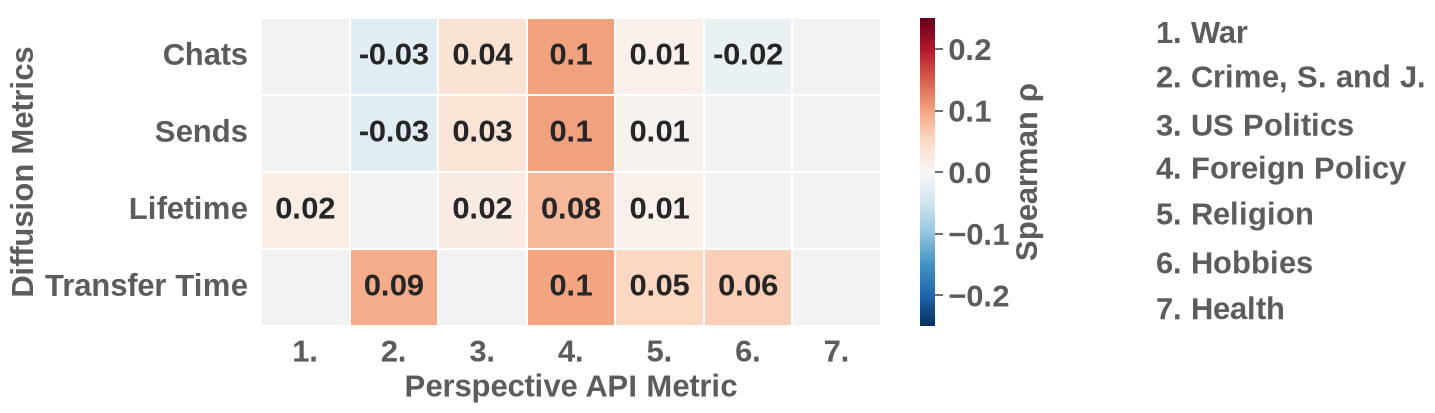

In [27]:
def apply_spearman_single(df, col_pivo, tox_col='perspective_toxicity'):
    all_results = []

    for topic, df_topic in df.groupby('macrotopic_pred'):
        tmp = df_topic[[col_pivo, tox_col]].dropna()

        if len(tmp) > 1:
            rho, p = spearmanr(tmp[col_pivo], tmp[tox_col])
        else:
            rho, p = None, None

        all_results.append({
            'macrotopic_pred': topic,
            'spearman_rho': rho,
            'p_value': p,
            'n': len(tmp)
        })

    results_df = pd.DataFrame(all_results)

    # agora vira uma série (não precisa pivot)
    rho_series = results_df.set_index('macrotopic_pred')['spearman_rho'].sort_index()
    p_series = results_df.set_index('macrotopic_pred')['p_value'].sort_index()

    return rho_series, p_series

dados_heatmap = []
pvalues_heatmap = []

metricas = [
    ('Chats', df_analise_canal, 'folder'),
    ('Sends', df, 'send_count'),
    ('Lifetime', df, 'lifetime'),
    ('Transfer Time', df, 'transfer_time')
]

for nome, dataframe, col in metricas:
    rho, p = apply_spearman_single(dataframe, col)
    
    rho = rho.reindex(ordem_desejada)
    p = p.reindex(ordem_desejada)

    dados_heatmap.append(rho)
    pvalues_heatmap.append(p)

heatmap_df = pd.DataFrame(dados_heatmap, index=[m[0] for m in metricas])
pvalues_df = pd.DataFrame(pvalues_heatmap, index=[m[0] for m in metricas])

plot_heatmap(
    heatmap_df,
    p_values=pvalues_df,
    title=None,
    vmin=-0.25,
    vmax=0.25,
    xlabel="Perspective API Metric",
    ylabel="Diffusion Metrics"
)

ax = plt.gca()

ax.set_xticklabels(
    [f"{i}." for i in range(1, len(ordem_desejada) + 1)],
    rotation=0
)

mapping = {i+1: topic for i, topic in enumerate(ordem_desejada)}

legend_text = "\n".join([f"{i}. {topic}" for i, topic in mapping.items()])

fig = plt.gcf()
fig.set_size_inches(10,4)

#plt.title('Toxicity vs Diffusion Metrics')
plt.savefig(f"{OUTPUT_DIR}/rq2/spearman_heatmap_global.{format}", format=format, bbox_inches='tight')
fig.text(
    1.02, 0.5,   
    legend_text,
    ha='left',
    va='center',
    linespacing=1.6
)

**Figure — 4-panel breakdown**, one heatmap per diffusion metric (chats/sends/lifetime/transfer time) × all six toxicity metrics side by side. Saves `rq2/spearman_heatmap.png`:

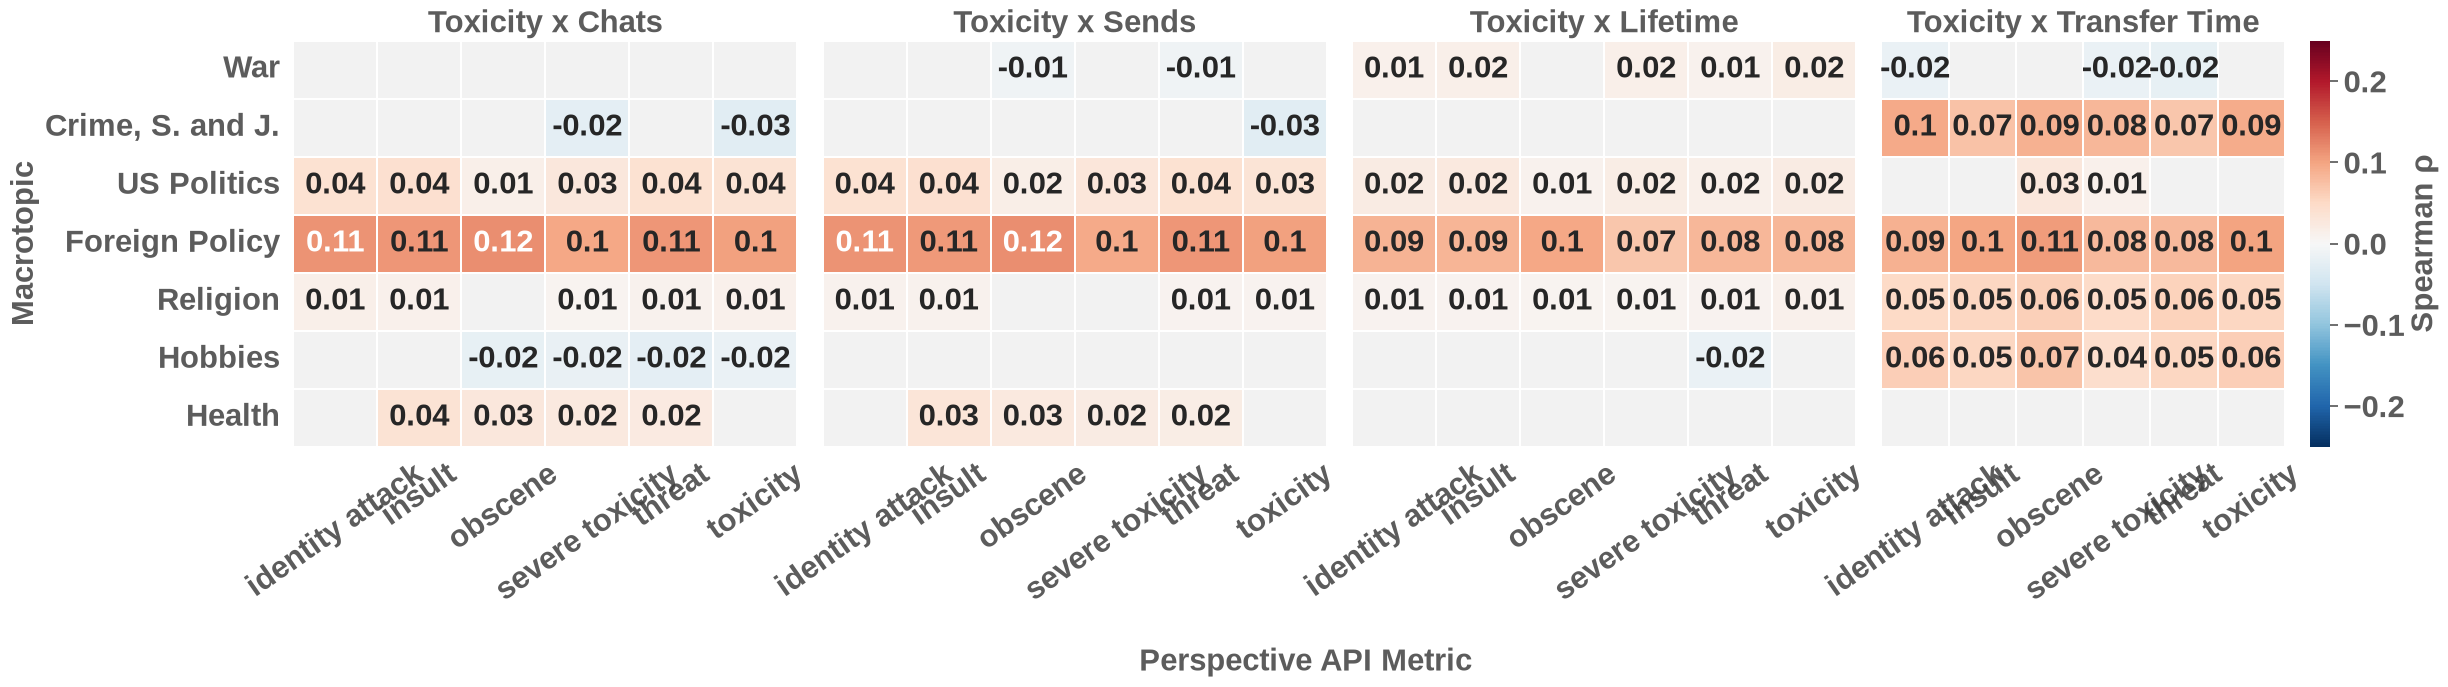

In [28]:
fig, axs = plt.subplots(1, 4, figsize=(27, 7), gridspec_kw={'width_ratios': [1, 1, 1, 1]})
fig.subplots_adjust(wspace=0.05)  # cola os gráficos

# --- GRÁFICO 1 ---
rho, p_vals = apply_spearman_correlation(df_analise_canal, 'folder', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)
plot_heatmap(rho, 'Toxicity x Chats', p_values=p_vals, vmin=-0.25, vmax=0.25, ax=axs[0], cbar=False)

# --- GRÁFICO 2 ---
rho, p_vals = apply_spearman_correlation(df, 'send_count', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)
plot_heatmap(rho, 'Toxicity x Sends', p_values=p_vals, vmin=-0.25, vmax=0.25, ax=axs[1], cbar=False, ylabel="")

# --- GRÁFICO 3 ---
rho, p_vals = apply_spearman_correlation(df, 'lifetime', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)
plot_heatmap(rho, 'Toxicity x Lifetime', p_values=p_vals, vmin=-0.25, vmax=0.25, ax=axs[2], cbar=False, ylabel="")

# --- GRÁFICO 4 ---
rho, p_vals = apply_spearman_correlation(df, 'transfer_time', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)
plot_heatmap(rho, 'Toxicity x Transfer Time', p_values=p_vals, vmin=-0.25, vmax=0.25, ax=axs[3], cbar=True, yticks=False, ylabel="")

# remove yticks dos gráficos 2 e 3
axs[1].tick_params(labelleft=False)
axs[2].tick_params(labelleft=False)

# xlabel centralizado único
fig.subplots_adjust(wspace=0.05, bottom=0.30)

# xlabel centralizado único - ajuste o y conforme necessário
fig.text(0.5, -0.02, 'Perspective API Metric', ha='center')

plt.savefig(f"{OUTPUT_DIR}/rq2/spearman_heatmap.{format}", format=format, bbox_inches='tight')
plt.show()

### Gráficos cumulativos

Aggregates to one row per video with `lifetime`, `send_count`, distinct channel count (`groups`), `transfer_time`, macrotopic and mean toxicity:

In [29]:
df_resumo = df_complete.groupby('video_id').agg({
    'lifetime': 'first',               
    'send_count': 'first',            
    'folder': 'nunique',
    'transfer_time': 'first',                   
    'macrotopic_pred': 'first',             
    'perspective_toxicity': 'mean'         
}).reset_index()

df_resumo.columns = ['video_id', 'lifetime', 'send_count', 'groups', 'transfer_time', 'macrotopic_pred', 'perspective_toxicity']
display(df_resumo.head())

,video_id,lifetime,send_count,groups,transfer_time,macrotopic_pred,perspective_toxicity
0,---HJCJANEk,1.0,1,1,1937.0,Religion,0.023995
1,--0HDiV4Wrk,1.0,1,1,85.0,Foreign Policy,0.005799
2,--0WrRVhu20,1.0,10,9,0.0,"Crime, S. and J.",0.008402
3,--0jTye5wh4,1.0,1,1,0.0,Religion,0.007362
4,--0o49GFj4U,1.0,1,1,0.0,Religion,0.004463


Sanity check: how many videos fall into each macrotopic in this summary table:

In [30]:
print(df_resumo['macrotopic_pred'].value_counts())
len(df_resumo)

macrotopic_pred
Religion            111071
US Politics          52998
War                  52846
Foreign Policy       40410
Hobbies              18913
Health               11522
Crime, S. and J.      9341
Name: count, dtype: int64


297101

Computes the topic breakdown and total count of videos sent only once — this is the basis for the 78% figure noted below:

In [31]:
# 1. Printar a distribuição por tópico (como você já estava fazendo)
print("Distribuição por tópico (envio único):")
print(df_resumo['macrotopic_pred'][df_resumo['send_count'] == 1].value_counts())

print("-" * 30)

# 2. Printar a quantidade TOTAL apenas uma vez
total_envio_unico = len(df_resumo[df_resumo['send_count'] == 1])
print(f"Total de vídeos com apenas 1 envio: {total_envio_unico}")

print(f"Vídeos que foram enviados mais de uma vez: {len(df_resumo) - total_envio_unico}")

Distribuição por tópico (envio único):
macrotopic_pred
Religion            64947
War                 33570
Foreign Policy      28580
US Politics         24819
Hobbies             13985
Health               6740
Crime, S. and J.     4094
Name: count, dtype: int64
------------------------------
Total de vídeos com apenas 1 envio: 176735
Vídeos que foram enviados mais de uma vez: 120366


78% dos vídeos são enviados apenas 1 vez, portanto tendo o alcance equivalente independente do tópico

Splits the per-video summary table into political vs. non-political subsets, for the CDF/CCDF comparisons below:

In [32]:
df_resumo['Politics']=df_resumo['macrotopic_pred'].apply(lambda x: x in politics)
df_politics=df_resumo[df_resumo['Politics']].copy()
df_non_politics=df_resumo[~df_resumo['Politics']].copy()

**Figure — CDF of number of sends**, political vs. non-political (main plot), with an inset breaking it down by individual macrotopic. Saves `rq2/cdf_sends.png`:

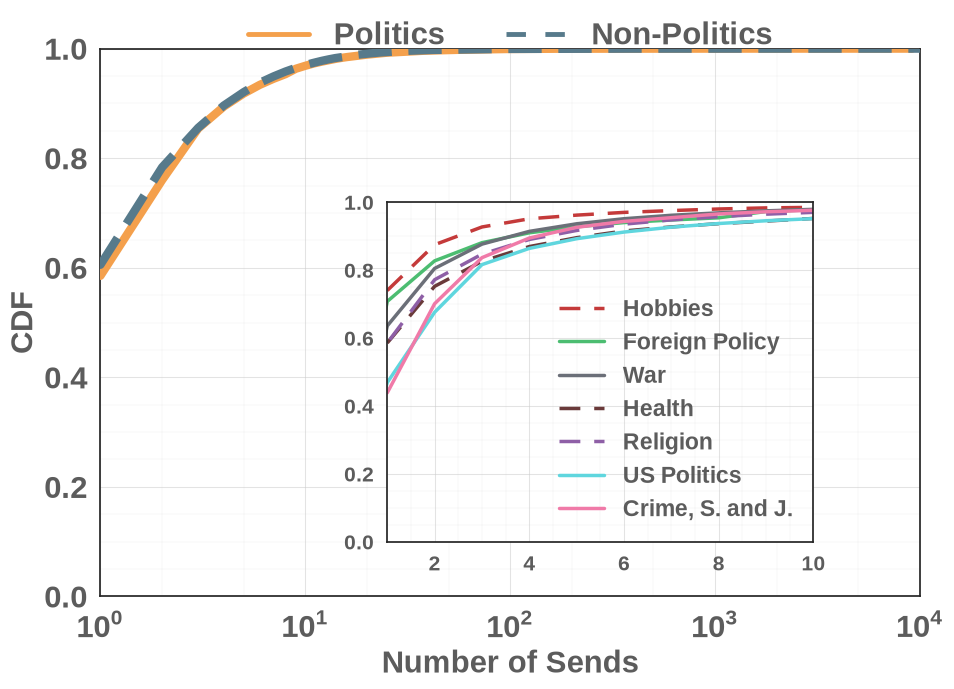

In [36]:
import numpy as np
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

value = 'send_count'

# Politics
x_sorted = df_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
y = np.array([(x_sorted <= v).sum() / n for v in xs])
ax.plot(xs, y, color=palette_map['War'], linestyle='solid', linewidth=6.0, zorder=3, label='Politics')

# Non-politics
x_sorted = df_non_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
y = np.array([(x_sorted <= v).sum() / n for v in xs])
ax.plot(xs, y, color=palette_map['Religion'], linestyle=(0, (4, 2)), linewidth=6.0, zorder=3, label='Non-Politics')

ax.set_xscale('log')
ax.set_xlim(1, 10000)
ax.set_ylim(0, 1)

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 5]))
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ax.set_xlabel('Number of Sends')
ax.set_ylabel('CDF')

# =======================
# INSET — canto inferior direito
# =======================
axin = ax.inset_axes([0.35, 0.1, 0.52, 0.62])

axin.set_axisbelow(True)
axin.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
axin.minorticks_on()
axin.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ponto_ordenacao = 1
ordem_series = df_resumo.groupby('macrotopic_pred')[value].apply(
    lambda x: (x <= ponto_ordenacao).mean()
)
hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()

for idx in hue_order_list:
    df_group = df_resumo[df_resumo['macrotopic_pred'] == idx]
    x_sorted = df_group[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([(x_sorted <= v).sum() / n for v in xs])
    linestyle = 'solid' if idx in politics else (0, (6, 4))
    axin.plot(xs, y, color=macro_colors[idx], linewidth=2.5, linestyle=linestyle, label=idx)

axin.set_xlim(1, 10)
axin.set_ylim(0, 1)
axin.set_ylabel('')
axin.set_facecolor('white')
axin.tick_params(labelsize=plt.rcParams['font.size'] * 0.7)
axin.legend(fontsize=plt.rcParams['font.size'] * 0.75, frameon=False, loc='lower right')

# Legenda global
legend_elements = [
    Line2D([0], [0], color=palette_map['War'], lw=3.5, linestyle='solid', label='Politics'),
    Line2D([0], [0], color=palette_map['Religion'], lw=3.5, linestyle=(0, (4, 4)), label='Non-Politics'),
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 1.05])
plt.savefig(f"{OUTPUT_DIR}/rq2/cdf_sends.{format}", format=format, dpi=300, bbox_inches='tight')
plt.show()

**Figure — CCDF (1 − CDF)** of the same distribution — highlights the tail (videos sent many times) more clearly than the CDF. Saves `rq2/ccdf_sends.png`:

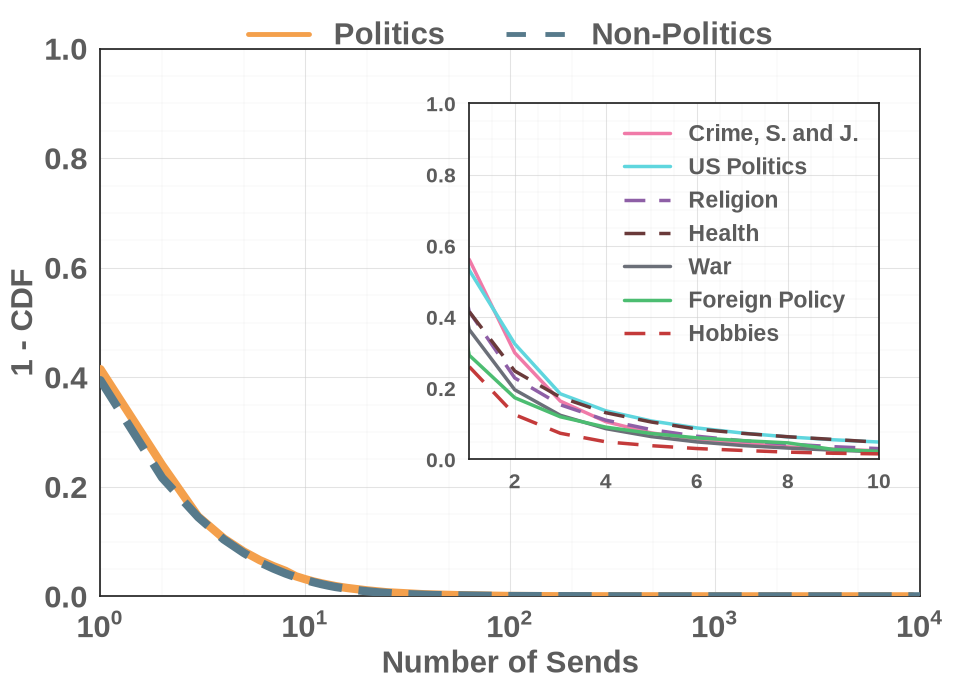

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

value = 'send_count'

# --- Política ---
x_sorted = df_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
# Mudança aqui: 1 - proporção acumulada
y = 1 - np.array([(x_sorted <= v).sum() / n for v in xs]) 
ax.plot(xs, y, color=palette_map['War'], linestyle='solid', linewidth=6.0, zorder=3, label='Politics')

# --- Não-Política ---
x_sorted = df_non_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
# Mudança aqui: 1 - proporção acumulada
y = 1 - np.array([(x_sorted <= v).sum() / n for v in xs])
ax.plot(xs, y, color=palette_map['Religion'], linestyle=(0, (4, 2)), linewidth=6.0, zorder=3, label='Non-Politics')

# Escala e Limites
ax.set_xscale('log')
# Para CCDFs de cauda longa, geralmente usa-se log no eixo Y também. 
# Se preferir linear, mantenha como está. Se quiser log-log, use: ax.set_yscale('log')
ax.set_xlim(1, 10000)
ax.set_ylim(0, 1) # Se usar log no Y, mude o limite inferior para algo como 1e-4

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 5]))
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ax.set_xlabel('Number of Sends')
ax.set_ylabel('1 - CDF') # Rótulo alterado

# =======================
# INSET — canto superior direito (ajustado para CCDF costuma ficar melhor no topo)
# =======================
# Ajustei as coordenadas do inset [x, y, largura, altura] para não sobrepor as linhas
axin = ax.inset_axes([0.45, 0.25, 0.50, 0.65])

axin.set_axisbelow(True)
axin.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
axin.minorticks_on()
axin.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ponto_ordenacao = 1
# A lógica de ordenação pode permanecer a mesma ou ser invertida dependendo do seu interesse
ponto_inicial = 1
ordem_series = df_resumo.groupby('macrotopic_pred')[value].apply(
    lambda x: (x > ponto_inicial).mean()
)
hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()

for idx in hue_order_list:
    df_group = df_resumo[df_resumo['macrotopic_pred'] == idx]
    x_sorted = df_group[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    # Mudança aqui: 1 - proporção acumulada
    y = 1 - np.array([(x_sorted <= v).sum() / n for v in xs])
    linestyle = 'solid' if idx in politics else (0, (6, 4))
    axin.plot(xs, y, color=macro_colors[idx], linewidth=2.5, linestyle=linestyle, label=idx)

axin.set_xlim(1, 10)
axin.set_ylim(0, 1)
axin.set_ylabel('')
axin.set_facecolor('white')
axin.tick_params(labelsize=plt.rcParams['font.size'] * 0.7)
axin.legend(fontsize=plt.rcParams['font.size'] * 0.75, frameon=False, loc='upper right')

# Legenda global
legend_elements = [
    Line2D([0], [0], color=palette_map['War'], lw=3.5, linestyle='solid', label='Politics'),
    Line2D([0], [0], color=palette_map['Religion'], lw=3.5, linestyle=(0, (4, 4)), label='Non-Politics'),
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 1.05])
plt.savefig(f"{OUTPUT_DIR}/rq2/ccdf_sends.{format}", format=format, dpi=300, bbox_inches='tight')
plt.show()

Portanto a massa dos vídeos tem um poder de difusão similar, uma característica de 1 envio, 1 canal, 1 dia
Vamos analisar agora os vídeos com quantidade de envio maior do que 2 para ver se quando um vídeo é repetido isso difere

Filters the summary table down to videos sent more than once, for the follow-up analysis the note above sets up:

In [38]:
df_resumo = df_resumo[df_resumo['send_count'] > 1].copy()
len(df_resumo)
df_politics=df_resumo[df_resumo['Politics']].copy()
df_non_politics=df_resumo[~df_resumo['Politics']].copy()

Bumps up font sizes for the wide 4-panel figure that follows:

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    font="Liberation Sans"
)

plt.rcParams.update({
    'font.family': 'Liberation Sans',

    # fontes escaladas para figuras largas (~27 width)
    'font.size': 34,
    'axes.titlesize': 36,
    'axes.labelsize': 36,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'legend.fontsize': 34,
    'figure.titlesize': 36,

    'text.color': "#3F3F3FD8",
    'axes.labelcolor': "#3F3F3FD8",
    'xtick.color': "#3F3F3FD8",
    'ytick.color': "#3F3F3FD8",

    'font.weight': 700,
    'axes.labelweight': 700,
    'axes.titleweight': 700,
})

format = 'png'

**Figure — 4-panel CCDF**, one panel per diffusion metric (sends/chats/lifetime/transfer time), each showing political vs. non-political vs. every individual macrotopic (faint background lines), log-log scale. Saves `rq2/ccdf_category_topic2.png`:

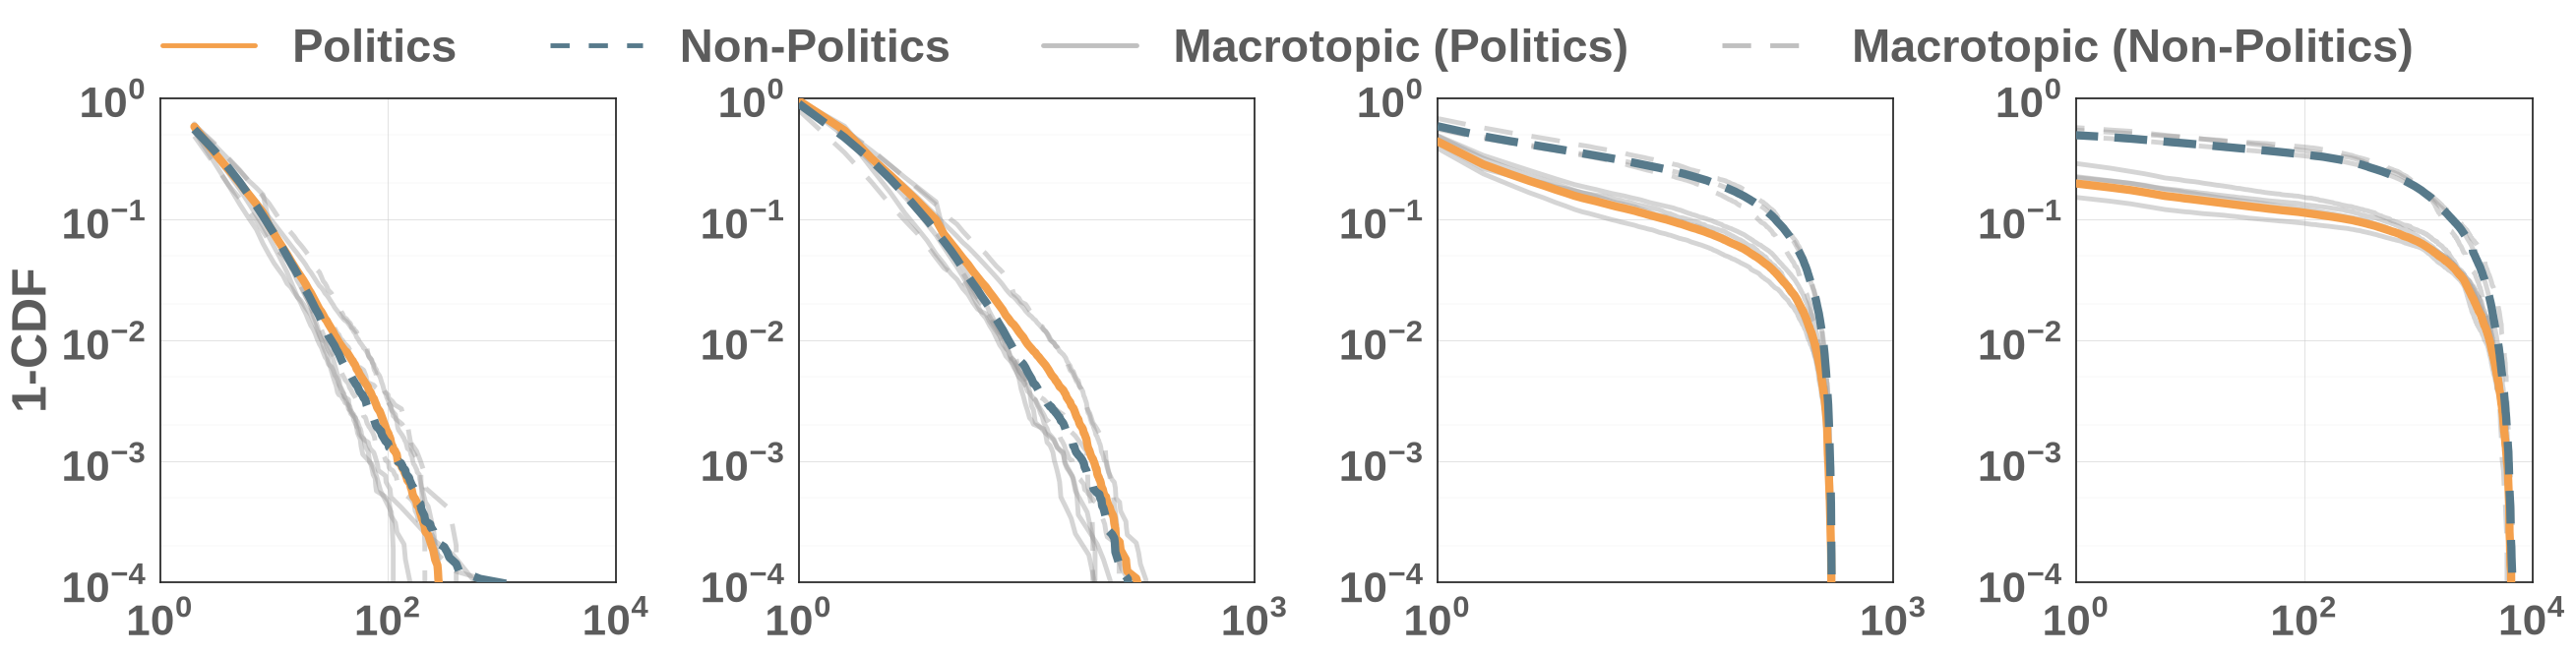

In [43]:
from matplotlib.lines import Line2D
import numpy as np

fig, axs = plt.subplots(figsize=(27, 7), ncols=4)
#fig.subplots_adjust(wspace=0.35)

to_plot = ['send_count','groups','lifetime','transfer_time']
macros_used = sorted(df_resumo['macrotopic_pred'].unique())

for ax, value in zip(axs, to_plot):
    # -------------------------------
    # Macrotópicos (apagados)
    # -------------------------------
    for idx, df_group in df_resumo.groupby('macrotopic_pred'):

        linestyle = (0, (6, 4)) if idx not in politics else 'solid'  

        x_sorted = df_group[value].sort_values().values
        n = len(x_sorted)

        if n == 0:
            continue

        xs = np.unique(x_sorted)
        y  = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

        ax.plot(
            xs, y,
            color="#979696",   
            linewidth=3.5,
            linestyle=linestyle,
            alpha=0.4,       
            zorder=1
        )

    # -------------------------------
    # Categoria: politics (forte)
    # -------------------------------
    x_sorted = df_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

    ax.plot(
        xs, y,
        color=palette_map['War'],
        linestyle='solid',
        linewidth=6.0,
        alpha=1.0,
        zorder=3
    )

    # -------------------------------
    # Categoria: non-politics (forte)
    # -------------------------------
    x_sorted = df_non_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

    ax.plot(
        xs, y,
        color=palette_map['Religion'],
        linestyle=(0, (4, 2)),  
        linewidth=6.0,
        alpha=1.0,
        zorder=3
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_axisbelow(True)

    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.yaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 5]))
    ax.xaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 5]))
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

# -------------------------------
# Limites e labels
# -------------------------------
axs[0].set_xlim(1,10000)
axs[0].set_ylim(1e-4,1)
#axs[0].set_xlabel('a.) Number of Sends')
axs[0].set_ylabel('1-CDF')

axs[1].set_xlim(1,1000)
axs[1].set_ylim(1e-4,1)
#axs[1].set_xlabel('b.) Number of Chats')

axs[2].set_xlim(1,1000)
axs[2].set_ylim(1e-4,1)
#axs[2].set_xlabel('c.) Lifetime (Days)')

axs[3].set_xlim(1,10000)
axs[3].set_ylim(1e-4,1)
#axs[3].set_xlabel('d.) Transfer Time (Days)')

legend_elements = [
    Line2D([0], [0], color=palette_map['War'], lw=3.5, linestyle='solid',
           label='Politics'),
    Line2D([0], [0], color=palette_map['Religion'], lw=3.5, linestyle=(0, (4, 4)),
           label='Non-Politics'),
    Line2D([0], [0], color="#979696", lw=3.5, linestyle='solid', alpha=0.6,
           label='Macrotopic (Politics)'),
    Line2D([0], [0], color="#979696", lw=3.5, linestyle=(0, (6, 4)), alpha=0.6,
           label='Macrotopic (Non-Politics)'),
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(f"{OUTPUT_DIR}/rq2/ccdf_category_topic2.{format}",format=format, dpi=300, bbox_inches='tight')
plt.show()

Derives composite diffusion-rate metrics per video: sends/day, distinct-channels/day, channels/send ("spread rate"), and sends relative to transfer time:

In [44]:
dfs = [df_resumo, df_politics, df_non_politics]

for df in dfs:
    df['intensidade_disparo'] = df['send_count'] / df['lifetime']
    df['velocidade_expansao'] = df['groups'] / df['lifetime']
    df['taxa_espalhamento']   = df['groups'] / df['send_count']
    df['transfer_lifetime']   = df['transfer_time'] / df['lifetime']
    df['send_transfer'] = df['send_count'] / (df['transfer_time'] + 1)

**Statistics table** — Mann-Whitney U test (two-sided) comparing political vs. non-political videos on each of those four derived rate metrics, reporting mean/std/median for both groups:

In [45]:
import pandas as pd
from scipy.stats import mannwhitneyu

metrics = {
    'Sends / Day':              'intensidade_disparo',
    'Groups / Day':             'velocidade_expansao',
    'Groups / Sends':           'taxa_espalhamento',
    'Sends / Transfer Time':    'send_transfer',
}

rows = []
for label, col in metrics.items():
    p   = df_politics[col].replace([np.inf, -np.inf], np.nan).dropna()
    np_ = df_non_politics[col].replace([np.inf, -np.inf], np.nan).dropna()
    
    stat, pval = mannwhitneyu(p, np_, alternative='two-sided')
    
    rows.append({
        'Metric':              label,
        'Politics Mean':       f"{p.mean():.3f}",
        'Politics Std':        f"{p.std():.3f}",
        'Politics Median':     f"{p.median():.3f}",
        'Non-Politics Mean':   f"{np_.mean():.3f}",
        'Non-Politics Std':    f"{np_.std():.3f}",
        'Non-Politics Median': f"{np_.median():.3f}"
    })

df_table = pd.DataFrame(rows).set_index('Metric')
display(df_table)

,Politics Mean,Politics Std,Politics Median,Non-Politics Mean,Non-Politics Std,Non-Politics Median
Metric,,,,,,
Sends / Day,2.484,7.806,2.000,1.685,10.460,1.500
Groups / Day,2.287,2.432,2.000,1.431,1.605,1.000
Groups / Sends,0.937,0.158,1.000,0.884,0.212,1.000
Sends / Transfer Time,4.252,37.073,2.000,3.918,155.344,1.500


___
## **RQ3 Analise temporal de envio do Telegram**

Font sizing for the RQ3 figures (larger than RQ1/RQ2, since these are wide multi-panel plots):

In [7]:
from matplotlib.lines import Line2D
plt.rcParams.update({
    'font.family': 'Liberation Sans',
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 30,
    'ytick.labelsize': 30,
    'legend.fontsize': 30,
    'figure.titlesize': 32,
})

`macro_styles` — per-macrotopic marker + linestyle combinations (solid lines/square-family markers for political topics, dashed/round-family markers for non-political), built from `macro_colors` — used by every weekly time-series plot in RQ3 from here on:

In [8]:
politics_markers     = ["s", "^", "D", "P", "H", "X"]
non_politics_markers = ["o", "v", "*", "p", "8", "h"]

macro_styles = {}

for i, macro in enumerate(politics):
    macro_styles[macro] = {
        "color":     macro_colors.get(macro, "#333333"),
        "linestyle": "solid",
        "marker":    politics_markers[i % len(politics_markers)],
        "markersize": 13,
        "linewidth": 3.5
    }

for i, macro in enumerate(non_politics):
    macro_styles[macro] = {
        "color":     macro_colors.get(macro, "#333333"),
        "linestyle": (0, (2, 2)),
        "marker":    non_politics_markers[i % len(non_politics_markers)],
        "markersize": 13,
        "linewidth": 3.5
    }

`plot_weekly_unique_toxicity_macros` — weekly mean toxicity per macrotopic, counting each video only once per week (deduplicated) even if it was sent multiple times that week:

In [9]:
def plot_weekly_unique_toxicity_macros(df, title_label, excluded_topics=None, output_fp="temporal"):
    if excluded_topics is None:
        excluded_topics = []

    # Limpeza e conversão básica
    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2024-12-01")].copy()
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start", "perspective_toxicity"])
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    # --- O PULO DO GATO ---
    # Removemos duplicatas para que cada vídeo conte apenas uma vez por semana/tópico
    # Se o mesmo vídeo aparece 10x na mesma semana, o drop_duplicates mantém apenas 1 entrada.
    df_unique_weekly = df.drop_duplicates(subset=["week_start", "macrotopic_pred", "video_id"])

    # Agora a média será sobre vídeos ÚNICOS
    grouped = (
        df_unique_weekly.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )
    # ----------------------

    macro_categories = sorted(grouped["macrotopic_pred"].unique())
    
    # Ordenação para a legenda (baseada na última semana)
    last_values = {m: grouped[grouped["macrotopic_pred"] == m].sort_values("week_start")["perspective_toxicity"].iloc[-1] 
                   if not grouped[grouped["macrotopic_pred"] == m].empty else 0 
                   for m in macro_categories}
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    plt.figure(figsize=(18, 8))
    ax = plt.gca()
    # ... (configurações de grid e estilo que você já tem) ...
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style.get("linewidth", 2),
            marker=style["marker"],
            markersize=style.get("markersize", 6),
            label=macro
        )

    # Configuração de Eixos
    week_list = sorted(grouped["week_start"].unique())
    plt.xticks(ticks=week_list[::2], labels=[w.strftime("%d-%m") for w in week_list[::2]], rotation=90)
    plt.xlim(week_list[0], week_list[-1])
    plt.ylabel("Mean Toxicity (Unique Videos)")
    plt.ylim(0, 0.18)

    # Reativando a legenda com a ordem correta
    handles = [Line2D([0], [0], color=macro_styles[m]["color"], linestyle=macro_styles[m]["linestyle"],
                      marker=macro_styles[m]["marker"], markersize=10, label=m) 
               for m in macro_categories_sorted if m in macro_styles]
    plt.legend(handles=handles, loc="upper left", frameon=True, facecolor="white", framealpha=0.8)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/rq3/{output_fp}.{format}", format=format, bbox_inches='tight')
    plt.show()

Calls it, excluding `Others`/`Technology`/`Entertainment`/`Environment`. **Figure** saves `rq3/toxicity_temporal.png`:

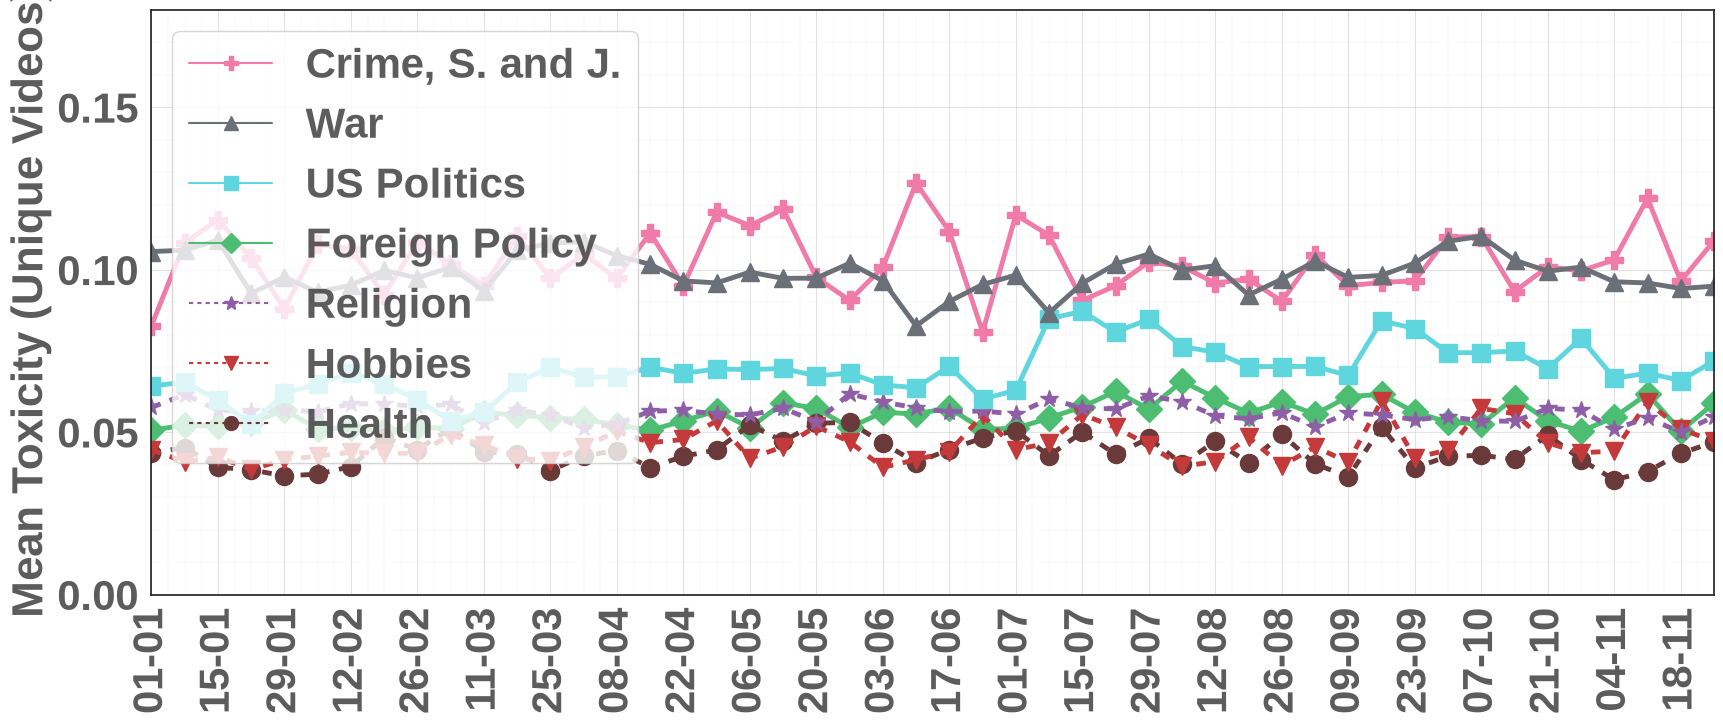

In [10]:
plot_weekly_unique_toxicity_macros(
    df_complete, 
    "All the data", 
    excluded_topics=["Others", "Technology", "Entertainment", "Environment"],
    output_fp="toxicity_temporal"
)

`plot_weekly_toxicity_macros` — same weekly-mean-toxicity idea, but **without** deduplicating repeat sends (every occurrence counts, not just one per video per week):

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import MultipleLocator

def plot_weekly_toxicity_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    # Limpeza e conversão de datas
    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # Início da semana real (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # Remover tópicos indesejados
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    # Agrupamento pela média de toxicidade
    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # Pegamos o valor da última semana disponível para cada tópico
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        if not m_df.empty:
            last_val = m_df["perspective_toxicity"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = 0
            
    # Reordena a lista baseada nos valores finais (Decrescente)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------------------------------

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 8))
    
    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    # Plotagem (usa a lista original para garantir que todas as linhas sejam desenhadas)
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style.get("linewidth"),
            marker=style["marker"],
            markersize = style.get("markersize"),
            label=macro
        )

    # Configuração das datas no eixo X
    week_list = sorted(grouped["week_start"].unique())
    week_ticks = week_list[::2]
    labels = [w.strftime("%d-%m") for w in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
        #fontsize=20  # aumentar tamanho dos ticks
    )
    #plt.yticks(fontsize=25)
    plt.xlim(week_list[0], week_list[-1])

    #plt.title(f"Weekly Evolution of Toxicity", fontsize=30)
    plt.xlabel("Week Start Date"
        #, fontsize=30
        )
    plt.ylabel("Mean Toxicity"
        #, fontsize=30
        )

    plt.ylim(0, 0.18)
    #plt.gca().yaxis.set_major_locator(MultipleLocator(0.01))

    """
    handles = [
        Line2D([0], [0],
            color=macro_styles[m]["color"],
            linestyle=macro_styles[m]["linestyle"],
            marker=macro_styles[m]["marker"],
            markersize=15,linewidth=3, label=m)
        for m in macro_categories_sorted
    ]

    
    legend = plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=26,
        #title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    # Ajuste fino do espaçamento interno da legenda
    legend._legend_box.sep = 6
    """

    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"{OUTPUT_DIR}/rq3/weekly_toxicity_macros.{format}", format=format, bbox_inches='tight')
    plt.show()

Calls it, same topic exclusions. **Figure** saves `rq3/weekly_toxicity_macros.png` — this is the one referenced by the paper for weekly toxicity, alongside the deduplicated version above:

In [ ]:
plot_weekly_toxicity_macros(
    df_complete, 
    "All the data", 
    excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
)

`plot_weekly_toxicity_macros_v2` — another variant (different styling, shows global mean±std as horizontal reference lines per topic). **Note: this one never calls `savefig`**, only `plt.show()` — looks like an exploratory alternative that wasn't promoted to a saved figure:

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import FancyBboxPatch

def plot_weekly_toxicity_macros_v2(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # 🔥 manter apenas uma ocorrência por vídeo
    df = df.drop_duplicates(subset=["video_id"]).copy()

    # início da semana real (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 remover tópicos indesejados
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA ---
    # Vamos pegar o valor da última semana disponível para cada tópico
    # para ordenar a legenda do maior (topo) para o menor (fundo).
    last_week = grouped["week_start"].max()
    
    # Cria um dicionário {topico: valor_ultima_semana}
    # Se um tópico não tiver dados na última semana exata, pegamos o último valor disponível dele.
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        if not m_df.empty:
            # Pega o último valor registrado (iloc[-1]) assumindo que o DF está ordenado por data
            # Como agrupamos, garantimos a ordenação:
            m_df = m_df.sort_values("week_start")
            last_val = m_df["perspective_toxicity"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = -1 # Joga pro final se não tiver dados
            
    # Reordena a lista de categorias baseada nesses valores (Decrescente)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------

    # --- estatísticas globais por macrotópico (ano todo) ---
    stats = (
        df.groupby("macrotopic_pred")["perspective_toxicity"]
          .agg(["mean", "std"])
          .reset_index()
          .rename(columns={"mean": "global_mean", "std": "global_std"})
    )

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 12))

    # Plotamos usando a lista original ou ordenada (tanto faz pro plot, mas usarei a original para iterar)
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        color = macro_colors.get(macro, "#333333")

        # linha temporal (média semanal)
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            marker="o",
            color=color,
            linewidth=2,
            zorder=3
        )

        # ---- média e desvio padrão anual do macrotópico ----
        row = stats[stats["macrotopic_pred"] == macro]

        if not row.empty:
            mu  = row["global_mean"].iloc[0]
            sd  = row["global_std"].iloc[0]

            # linha da média anual
            plt.hlines(
                y=mu,
                xmin=m_df["week_start"].min(),
                xmax=m_df["week_start"].max(),
                colors=color,
                linestyles="dashed",
                linewidth=4,
                alpha=1.0,
                zorder=2
            )


    # 🔥 Datas no padrão inglês
    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(week_list, labels, rotation=90, fontsize=25)
    plt.yticks(fontsize=35)

    plt.title(f"Weekly Evolution of Toxicity — {title_label}", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Mean Toxicity (Unique Videos)", fontsize=30)

    # Cria handles usando a lista ORDENADA (macro_categories_sorted)
    handles = [
        Line2D([0], [0], marker="s", linestyle="", 
               color=macro_colors[m], markersize=20, label=m)
        for m in macro_categories_sorted
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=26,
        title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    plt.ylim(0.03, 0.13)

    plt.tight_layout()
    plt.show()

Calls it — output not saved to disk, only rendered inline:

In [95]:
plot_weekly_toxicity_macros_v2(df_complete, "All the data")

NameError: name 'plot_weekly_toxicity_macros_v2' is not defined

`plot_weekly_video_count_macros_v1` — weekly video count per macrotopic (raw count, not deduplicated). Saves `gráficos/weekly_send_count.png` (note the different output folder — see the path-inconsistency note at the top of this notebook):

In [ ]:
def plot_weekly_video_count_macros_v1(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["video_id"]
          .count()
          .reset_index(name="video_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        last_values[macro] = m_df["video_count"].iloc[-1] if not m_df.empty else 0

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 11))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)


    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(
            macro,
            {"color": "#333333", "linestyle": "solid", "marker": "o"}
        )

        plt.plot(
            m_df["week_start"],
            m_df["video_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 10),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )
    
    week_list = sorted(grouped["week_start"].unique())
    week_ticks = week_list[::2]
    labels = [w.strftime("%d-%m") for w in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
        #fontsize=20  # aumentar tamanho dos ticks
    )
    #plt.yticks(#fontsize=25)
    plt.xlim(week_list[0], week_list[-1])
    

    #plt.title(f"Weekly Number of Videos", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("Number of Videos"
               #, fontsize=30
               )

    plt.ylim(0, 15000)
    plt.gca().yaxis.set_major_locator(MultipleLocator(3000))

    handles = [
        Line2D([0], [0],
            color=macro_styles[m]["color"],
            linestyle=macro_styles[m]["linestyle"],
            marker=macro_styles[m]["marker"],
            markersize=15,linewidth=3, label=m)
        for m in macro_categories_sorted
    ]

    legend = plt.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=4,
        frameon=False,
        handlelength=1.5,
        handletextpad=0.5,
        columnspacing=1.5
    )

    """
    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=26,
        #title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )
    """
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_send_count.{format}", format=format, dpi=300, bbox_inches='tight')
    plt.show()

Calls it:

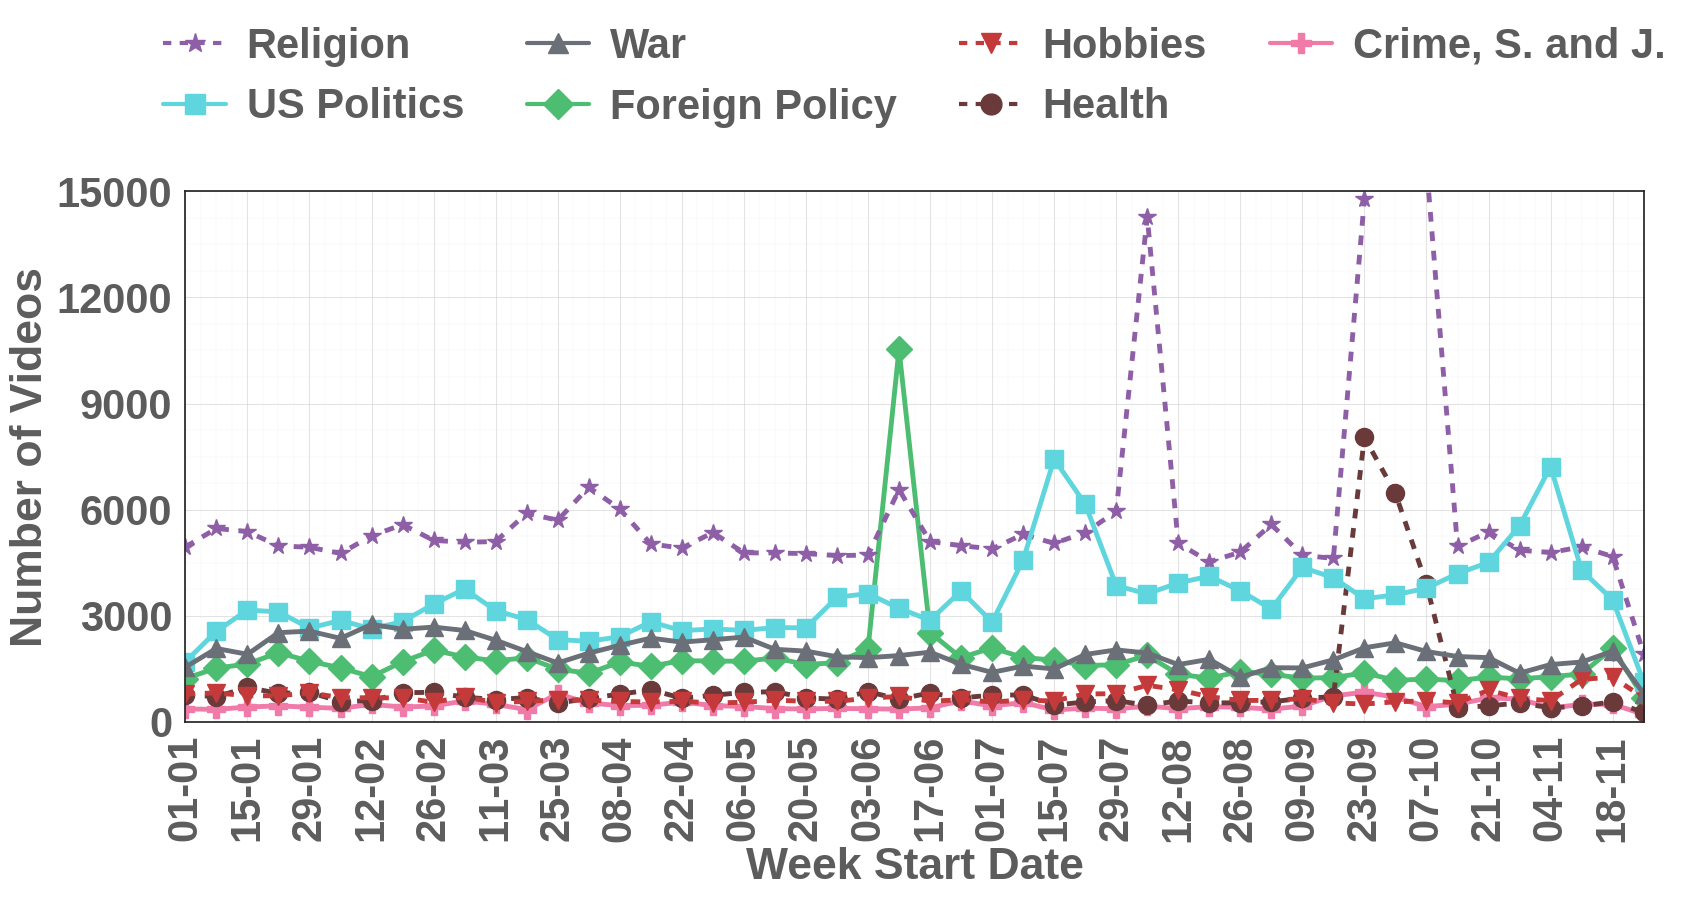

In [129]:
plot_weekly_video_count_macros_v1(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

`plot_weekly_video_count_macros` — the deduplicated version (one count per unique video per week), with week numbers instead of dates on the x-axis. Saves `gráficos/weekly_unique_video_count.png`:

In [101]:
def plot_weekly_video_count_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    df_unique = df.drop_duplicates(subset=["video_id", "week_start", "macrotopic_pred"]).copy()

    week_list = sorted(df_unique["week_start"].unique())
    week_map  = {w: i + 1 for i, w in enumerate(week_list)}
    df_unique["week_num"] = df_unique["week_start"].map(week_map)

    grouped = (
        df_unique.groupby(["week_num", "macrotopic_pred"])["video_id"]
        .nunique()
        .reset_index(name="video_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_num")
        last_values[macro] = m_df["video_count"].iloc[-1] if not m_df.empty else -1

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 8))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_num"],
            m_df["video_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_ticks = list(range(1, len(week_list)+1, 2))
    labels = [week_list[i-1].strftime("%d-%m") for i in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
    )
    #plt.yticks(fontsize=25)
    plt.xlim(1, len(week_list))

    #plt.title(f"Weekly Number of Unique Videos", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("Number of Unique Videos"
               #, fontsize=30
               )
    lim_y = 4000
    plt.ylim(0, lim_y)
    #plt.gca().yaxis.set_major_locator(MultipleLocator(lim_y/10))
    """
    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=20, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    legend = plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=26,
        #title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    legend._legend_box.sep = 6
    """
    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_unique_video_count.{format}", format=format, bbox_inches='tight')
    plt.show()

Calls it:

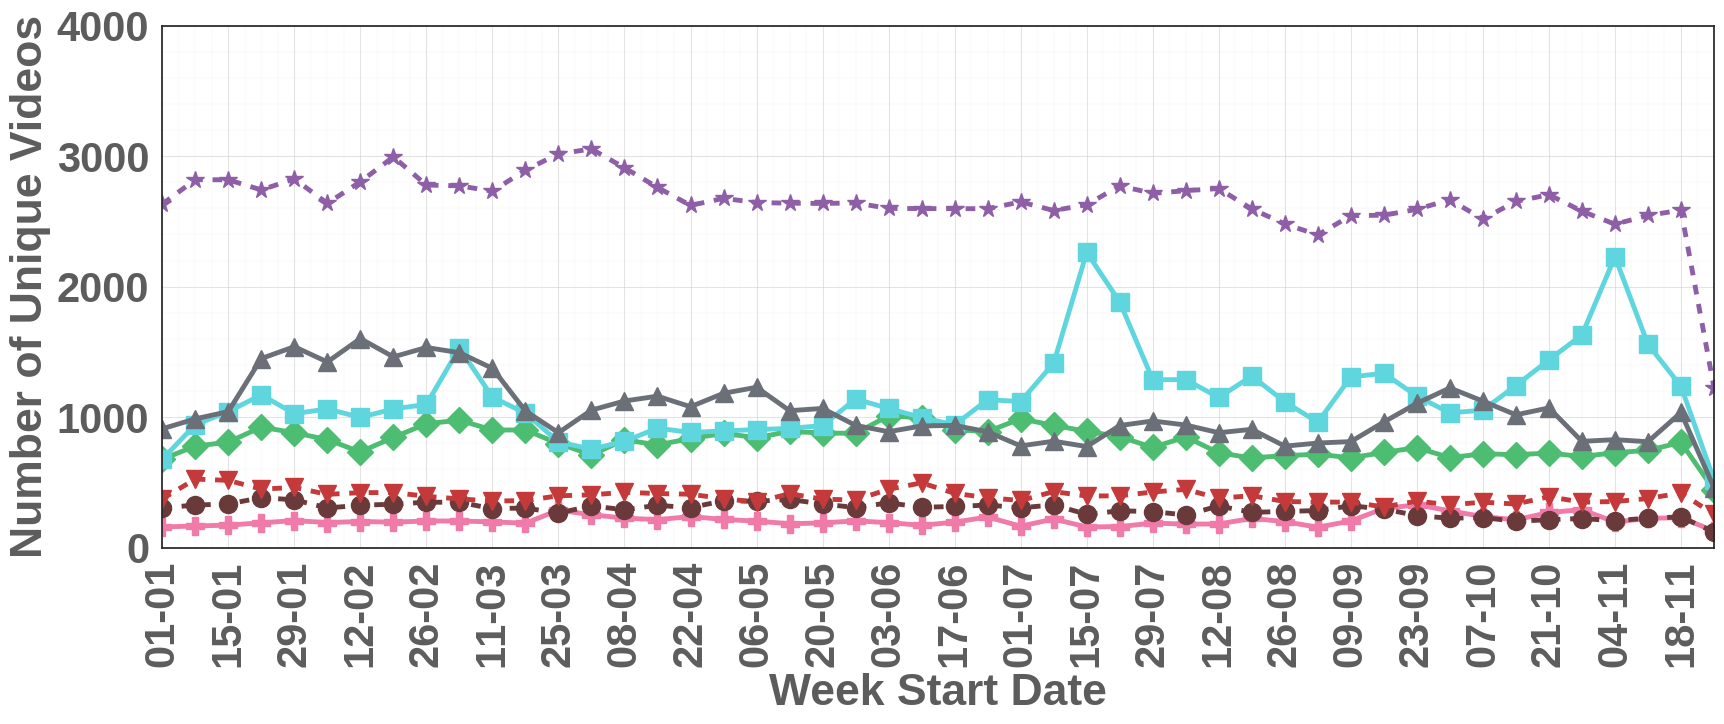

In [102]:
plot_weekly_video_count_macros(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

`plot_weekly_channel_count_macros` — weekly count of distinct Telegram channels active per macrotopic. Saves `gráficos/weekly_chats_count.png`:

In [120]:
def plot_weekly_channel_count_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"])

    grouped = (
        df_unique
        .groupby(["week_start", "macrotopic_pred"])["folder"]
        .nunique()
        .reset_index(name="channel_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        last_values[macro] = m_df["channel_count"].iloc[-1] if not m_df.empty else -1

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 8))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    week_ticks = week_list[::2]
    labels = [w.strftime("%d-%m") for w in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
        #fontsize=20  # aumentar tamanho dos ticks
    )
    #plt.yticks(fontsize=25)
    plt.xlim(week_list[0], week_list[-1])

    #plt.title(f"Weekly Number of Active Channels", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("Number of Active Chats"
               #, fontsize=30
               )

    plt.gca().yaxis.set_major_locator(MultipleLocator(200))

    """
    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=15, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=24,
        #title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )
    """
    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_chats_count.{format}", format=format, bbox_inches='tight')
    plt.show()

Calls it:

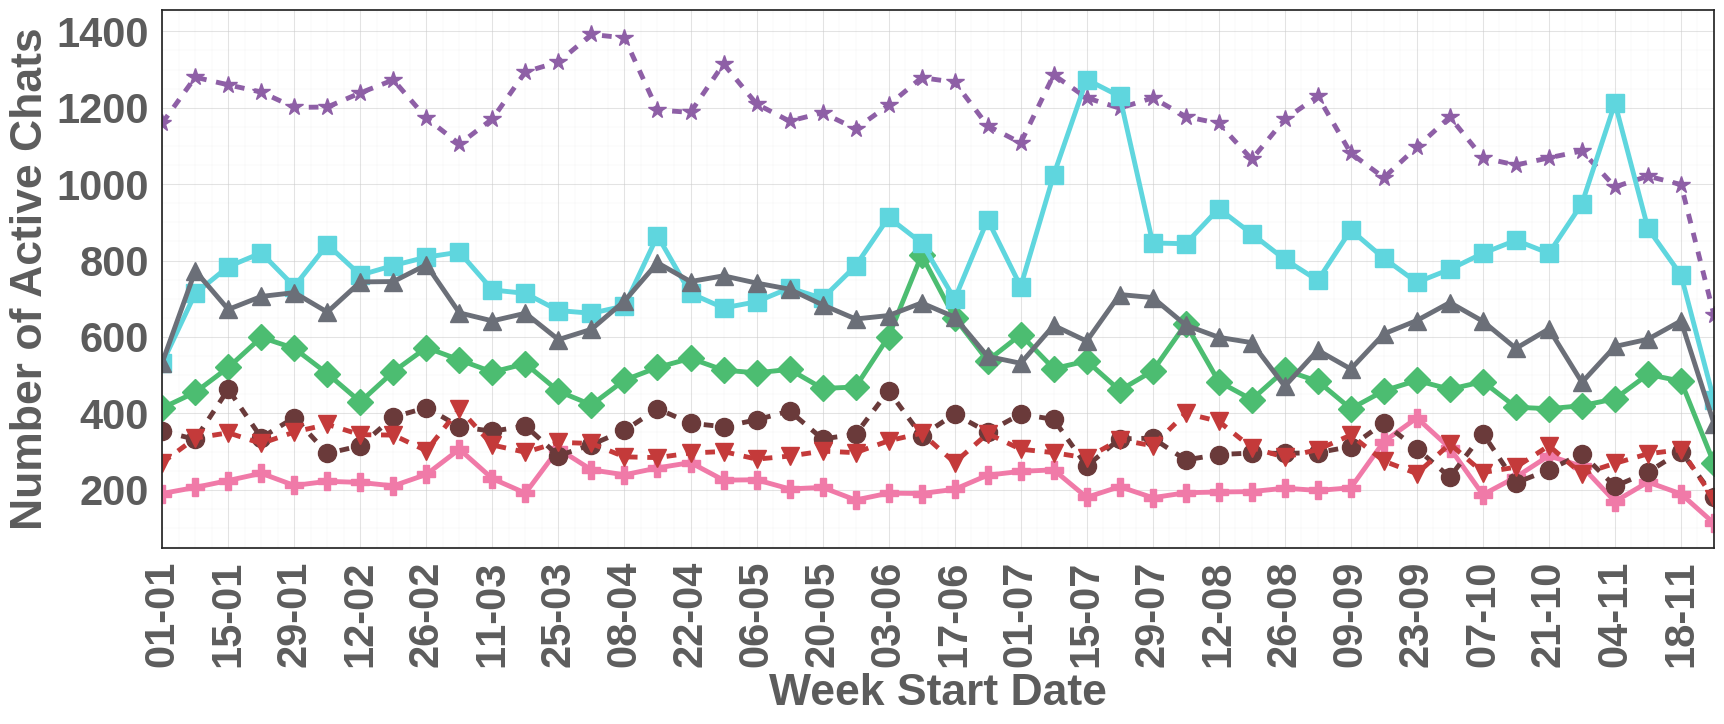

In [121]:
plot_weekly_channel_count_macros(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

`plot_weekly_channel_count_macros_2` — **cumulative** version: running total of distinct channels seen so far, per macrotopic, per week. Saves `gráficos/weekly_cumulative_chats_count.png`:

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def plot_weekly_channel_count_macros_2(df, title_label, excluded_topics=None):
    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    # início da semana (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 garantir uma ocorrência por canal por semana por tópico
    df_unique = df.drop_duplicates(
        subset=["folder", "week_start", "macrotopic_pred"]
    )

    # Ordenar cronologicamente
    df_unique = df_unique.sort_values("week_start")

    # Tabela acumulativa
    grouped = []

    for macro, m_df in df_unique.groupby("macrotopic_pred"):

        seen_channels = set()
        weekly = []

        for week, w_df in m_df.groupby("week_start"):
            new_channels = set(w_df["folder"]) - seen_channels
            seen_channels |= set(w_df["folder"])

            weekly.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "channel_count": len(seen_channels)   # 🔥 acumulado
            })

        grouped.extend(weekly)

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA (NOVO) ---
    # 1. Identifica o valor acumulado final para cada tópico
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        if not m_df.empty:
            # Como é cumulativo e ordenado por data, o último registro é o máximo
            m_df = m_df.sort_values("week_start")
            last_val = m_df["channel_count"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = -1

    # 2. Cria a lista ordenada (Decrescente pelo valor acumulado)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------------

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 8))
    #plt.grid(axis="x", visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(
            macro, {"color": "#333333", "linestyle": "solid", "marker": "o"}
        )

        plt.plot(
            m_df["week_start"],
            m_df["channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=style.get("markersize", 12),
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    week_ticks = week_list[::2]
    labels = [w.strftime("%d-%m") for w in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
        #fontsize=20  # aumentar tamanho dos ticks
    )
    plt.xlim(week_list[0], week_list[-1])

    #plt.yticks(fontsize=25)

    #plt.title(f"Cumulative Number of Unique Channels", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("Cumulative Unique Chats"
               #, fontsize=30
               )
    plt.gca().yaxis.set_major_locator(MultipleLocator(1000))

    """
    handles = [
        Line2D(
            [0], [0],
            color=macro_styles[m]["color"],
            linestyle=macro_styles[m]["linestyle"],
            marker=macro_styles[m]["marker"],
            markersize=macro_styles[m].get("markersize", 12),
            linewidth=macro_styles[m].get("linewidth", 2),
            label=m
        )
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=24,
        #title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )
    """

    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_cumulative_chats_count.{format}", format=format, bbox_inches='tight')
    plt.show()

Calls it:

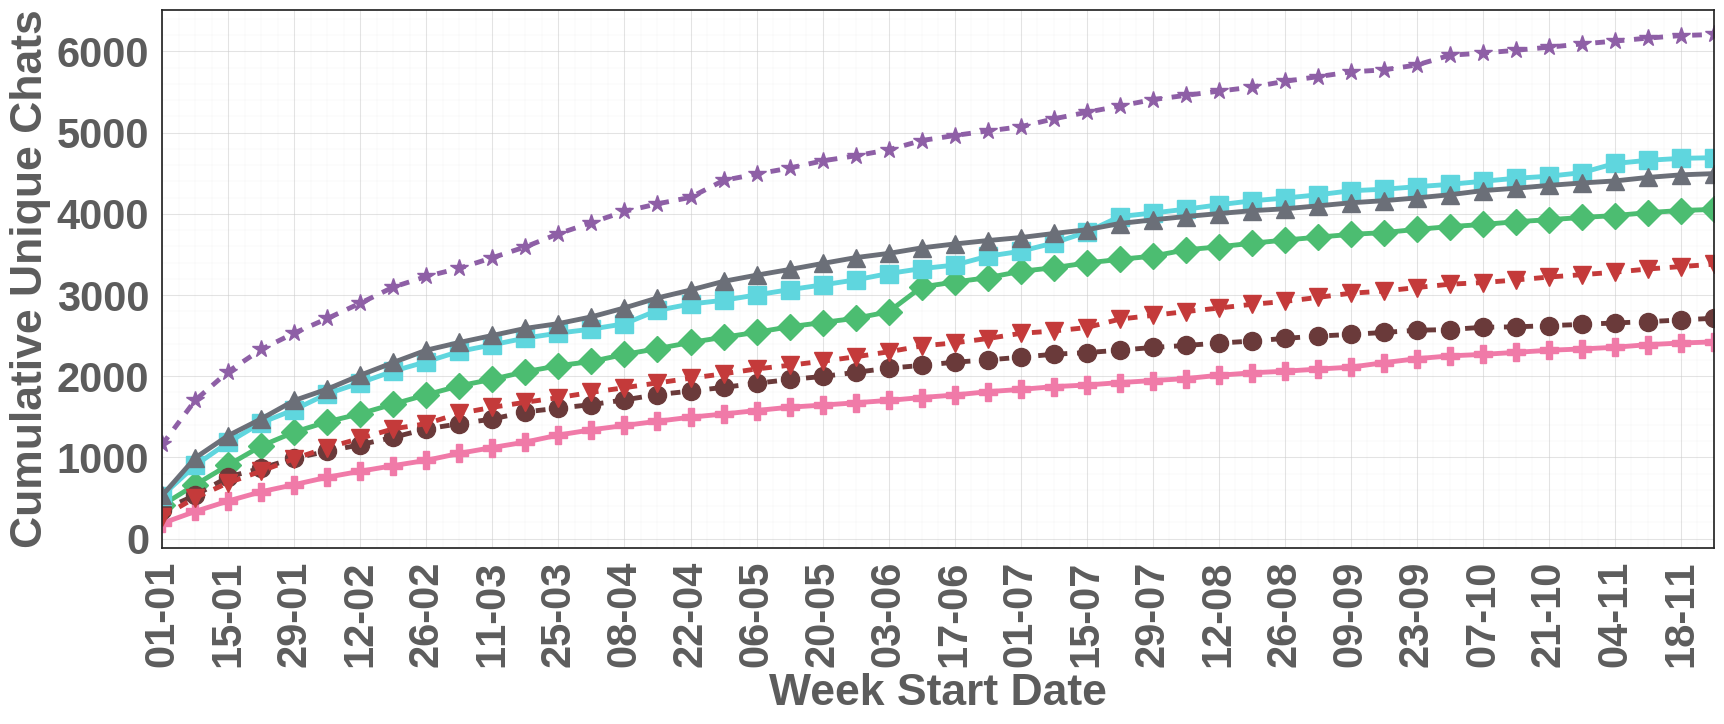

In [125]:
plot_weekly_channel_count_macros_2(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"])

`plot_weekly_new_channel_count_macros` — weekly count of *newly seen* channels per macrotopic (not cumulative). **No `savefig`** — exploratory, superseded by the "zoom" version below:

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def plot_weekly_new_channel_count_macros(df, title_label):

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # início da semana
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # uma ocorrência por canal / semana / tópico
    df_unique = df.drop_duplicates(
        subset=["folder", "week_start", "macrotopic_pred"]
    )

    df_unique = df_unique.sort_values("week_start")

    grouped = []

    for macro, m_df in df_unique.groupby("macrotopic_pred"):

        seen_channels = set()

        for week, w_df in m_df.groupby("week_start"):

            current_channels = set(w_df["folder"])
            new_channels = current_channels - seen_channels

            seen_channels |= current_channels

            grouped.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --------- ordenação da legenda (pela soma de novos canais no ano) ---------
    total_new = (
        grouped
        .groupby("macrotopic_pred")["new_channel_count"]
        .sum()
        .to_dict()
    )

    macro_categories_sorted = sorted(
        macro_categories,
        key=lambda x: total_new.get(x, 0),
        reverse=True
    )
    # --------------------------------------------------------------------------

    #sns.set(style="whitegrid")
    plt.figure(figsize=(27, 7))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})

        plt.plot(
            m_df["week_start"],
            m_df["new_channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d") for w in week_list]

    plt.xticks(
        ticks=week_list,
        labels=labels,
        rotation=90
        #fontsize=25
    )
    plt.xlim(week_list[0], week_list[-1])
    #plt.yticks(fontsize=30)

    #plt.title(f"Weekly New Unique Channels — {title_label}", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("New Unique Channels"
        #, fontsize=30
        )

    handles = [
        Line2D([0], [0], marker="s", linestyle="",
               color=macro_colors[m], markersize=15, label=m)
        for m in macro_categories_sorted
    ]

    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=24,
        #title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )

    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.show()


Calls it — output not saved to disk:

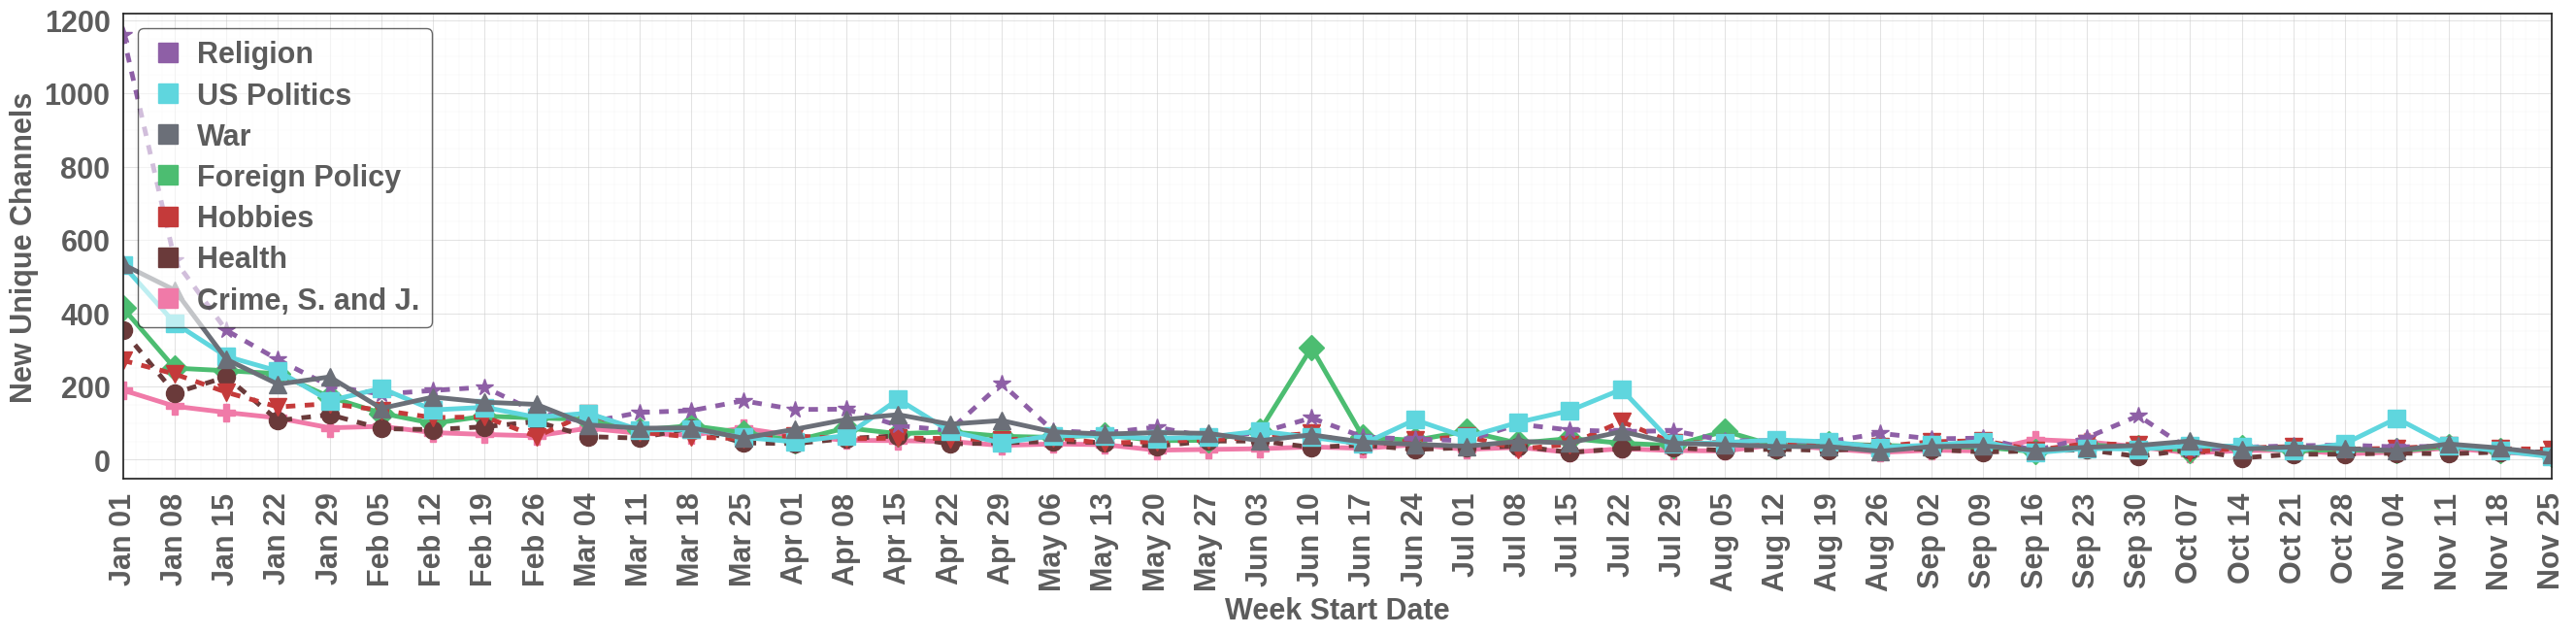

In [40]:
plot_weekly_new_channel_count_macros(df_complete, "All the data")

`plot_weekly_new_channel_count_macros_zoom` — same as above with a fixed y-axis limit (zoomed in). Saves `gráficos/weekly_new_channel_count.png`:

In [22]:
from matplotlib.ticker import MultipleLocator

def plot_weekly_new_channel_count_macros_zoom(df, title_label):

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"])
    df_unique = df_unique.sort_values("week_start")

    grouped = []
    for macro, m_df in df_unique.groupby("macrotopic_pred"):
        seen_channels = set()
        for week, w_df in m_df.groupby("week_start"):
            current_channels = set(w_df["folder"])
            new_channels = current_channels - seen_channels
            seen_channels |= current_channels
            grouped.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    total_new = grouped.groupby("macrotopic_pred")["new_channel_count"].sum().to_dict()
    macro_categories_sorted = sorted(macro_categories, key=lambda x: total_new.get(x, 0), reverse=True)

    #sns.set(style="whitegrid")
    plt.figure(figsize=(27, 7))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["new_channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d") for w in week_list]

    plt.xticks(ticks=week_list, labels=labels, rotation=90
               #, fontsize=25
               )
    #plt.yticks(fontsize=30)
    plt.xlim(week_list[0], week_list[-1])

    #plt.title(f"Weekly New Unique Channels",fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("New Unique Channels"
               #, fontsize=30
               )
    plt.ylim(0, 500)
    #plt.gca().yaxis.set_major_locator(MultipleLocator(50))

    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=15, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=24,
        #title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )

    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_new_channel_count.{format}", format=format, bbox_inches='tight')
    plt.show()

Calls it:

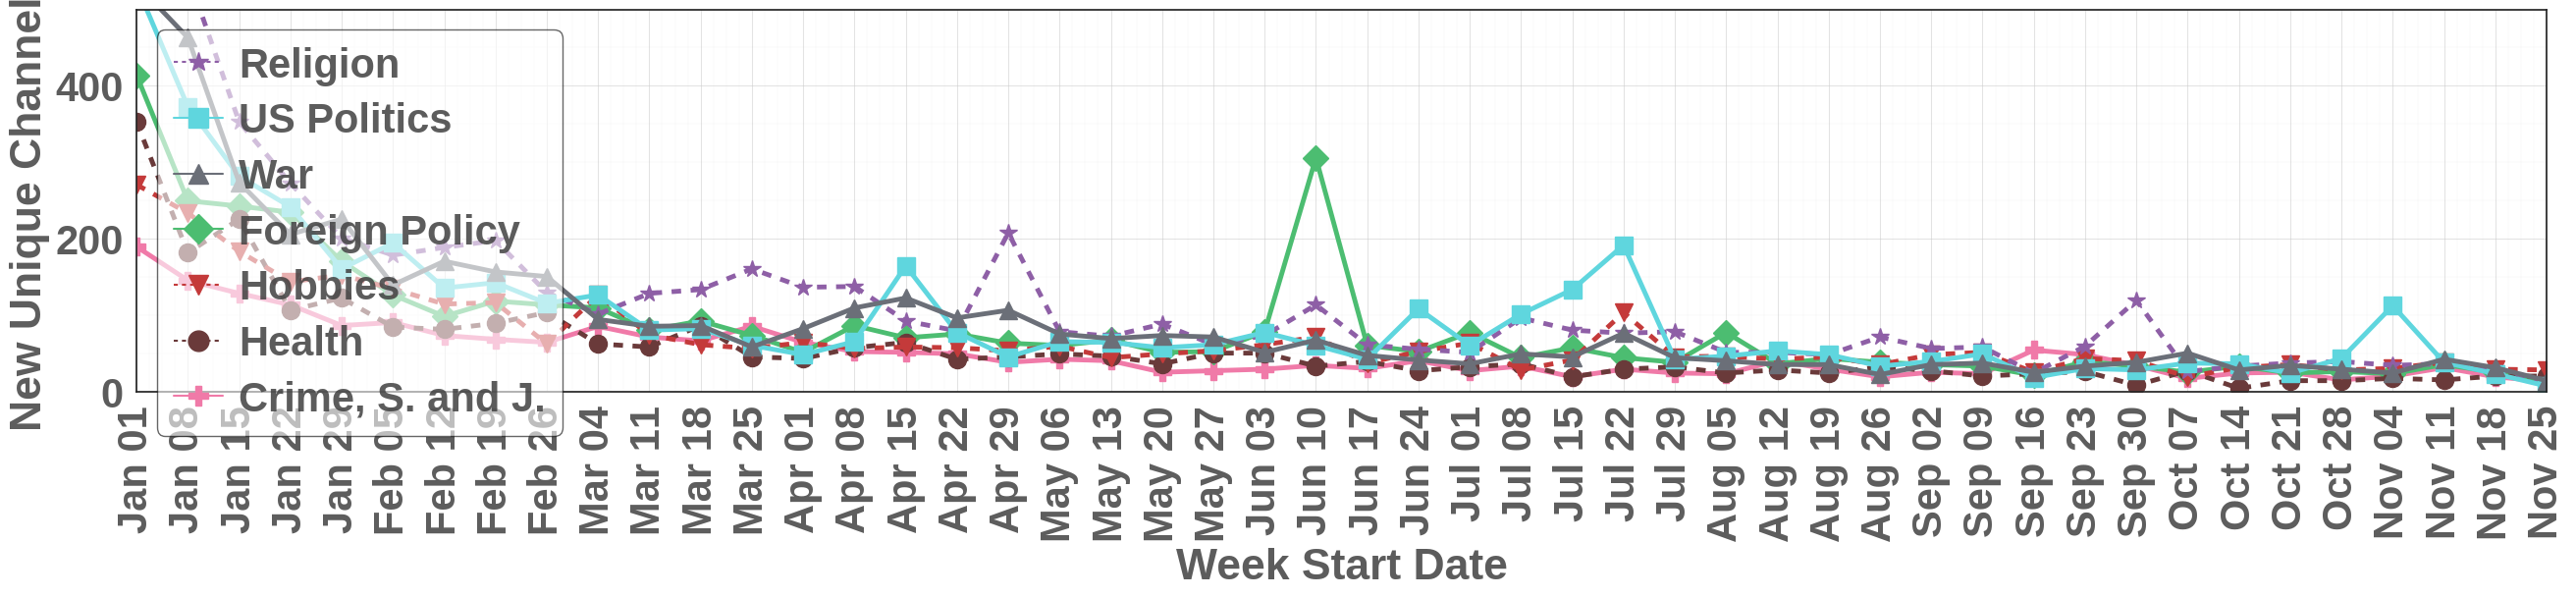

In [26]:
plot_weekly_new_channel_count_macros_zoom(df_complete, "All the data")

`plot_weekly_channels_combined` — overlays two lines per macrotopic in one figure: active channel count (colored, per topic style) and newly-seen channel count (thin gray line). Saves `gráficos/weekly_channel_and_new_count.png`:

In [61]:
def plot_weekly_channels_combined(df, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    # ----------------------------
    # ACTIVE CHANNELS
    # ----------------------------
    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"])

    active = (
        df_unique
        .groupby(["week_start", "macrotopic_pred"])["folder"]
        .nunique()
        .reset_index(name="channel_count")
    )

    # ----------------------------
    # NEW CHANNELS
    # ----------------------------
    df_unique = df_unique.sort_values("week_start")

    new_list = []

    for macro, m_df in df_unique.groupby("macrotopic_pred"):

        seen_channels = set()

        for week, w_df in m_df.groupby("week_start"):

            current = set(w_df["folder"])
            new_channels = current - seen_channels
            seen_channels |= current

            new_list.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    new_df = pd.DataFrame(new_list)

    macro_categories = sorted(active["macrotopic_pred"].unique())

    plt.figure(figsize=(20,7))
    ax = plt.gca()

    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:

        active_df = active[active["macrotopic_pred"] == macro]
        new_macro_df = new_df[new_df["macrotopic_pred"] == macro]

        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})

        # Linha principal (canais ativos) — mantém exatamente o seu padrão
        plt.plot(
            active_df["week_start"],
            active_df["channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=style.get("markersize", 12),
            linewidth=style.get("linewidth", 2),
            label=macro
        )

        # Linha cinza fina (novos canais)
        plt.plot(
            new_macro_df["week_start"],
            new_macro_df["new_channel_count"],
            color="gray",
            linestyle="solid",
            marker=style["marker"],
            markersize=10,
            linewidth=2,
            alpha=0.7
        )

    week_list = sorted(active["week_start"].unique())
    labels = [w.strftime("%b %d") for w in week_list]

    plt.xticks(week_list, labels, rotation=90)
    plt.xlim(week_list[0], week_list[-1])

    plt.xlabel("Week Start Date")
    plt.ylabel("Number of Channels")

    handles = [
        Line2D([0],[0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=15,
               label=m)
        for m in macro_categories if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black"
    )

    plt.tight_layout()
    plt.savefig(f"gráficos/weekly_channel_and_new_count.{format}", format=format, bbox_inches='tight')
    plt.show()

Calls it:

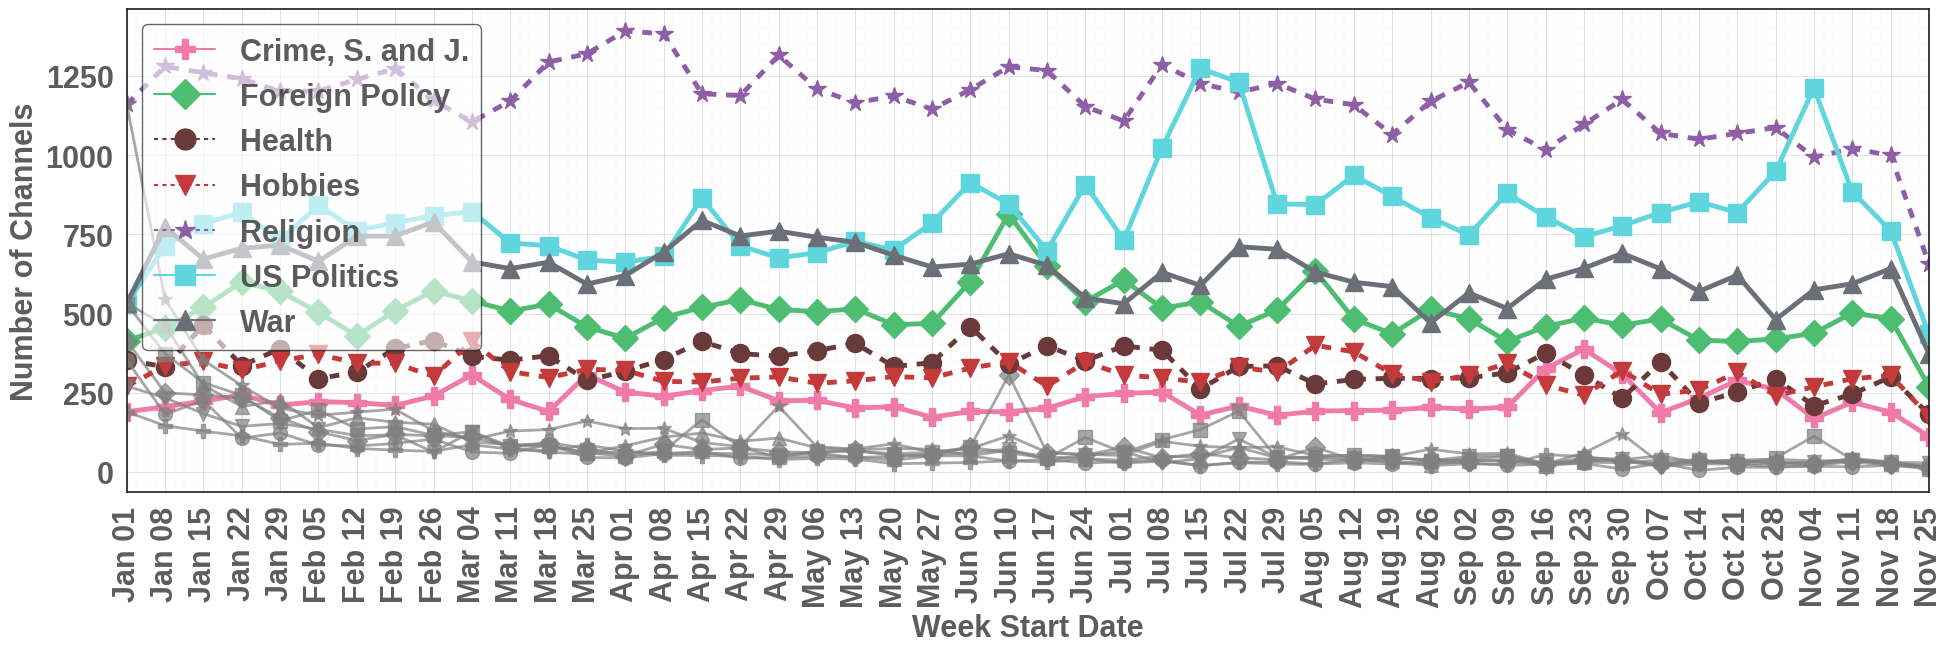

In [62]:
plot_weekly_channels_combined(df_complete)

`calculate_diffusion_metrics` — no figure here, just a printed statistic: for each macrotopic, finds how many weeks it took to reach a given percentage (default 80%) of its total eventual channel reach, then averages that across topics. Likely the source of an in-text number in the paper (e.g. "on average, topics reach 80% of their eventual channel reach within X weeks"):

In [29]:
def calculate_diffusion_metrics(df, threshold=80):
    # 1. Preparação idêntica à sua função de plot
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2024-12-01")].copy()
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    
    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"]).sort_values("week_start")

    grouped_data = []
    
    # 2. Lógica de "New Channels" (sua lógica original)
    for macro, m_df in df_unique.groupby("macrotopic_pred"):
        seen_channels = set()
        for week, w_df in m_df.groupby("week_start"):
            current_channels = set(w_df["folder"])
            new_channels = current_channels - seen_channels
            seen_channels |= current_channels

            grouped_data.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    grouped = pd.DataFrame(grouped_data)

    # 3. Cálculo da Porcentagem Cumulativa
    # Total de canais únicos por macrotópico ao fim do período
    total_per_macro = grouped.groupby("macrotopic_pred")["new_channel_count"].sum()
    
    # Acumulado semana a semana
    grouped['cumulative_new'] = grouped.groupby("macrotopic_pred")["new_channel_count"].cumsum()
    
    # Porcentagem do total atingida naquela semana
    grouped['pct_reached'] = grouped.apply(
        lambda x: (x['cumulative_new'] / total_per_macro[x['macrotopic_pred']]) * 100, axis=1
    )

    # 4. Encontrar em qual semana cada tópico atingiu o threshold (ex: 80%)
    reach_weeks = []
    for macro in total_per_macro.index:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        # Pega a primeira linha onde a porcentagem >= threshold
        milestone = m_df[m_df['pct_reached'] >= threshold].iloc[0]
        
        # Calcula a distância em semanas desde a primeira semana de dados
        start_date = m_df["week_start"].min()
        weeks_passed = (milestone["week_start"] - start_date).days // 7
        reach_weeks.append(weeks_passed)

    avg_weeks = sum(reach_weeks) / len(reach_weeks)
    
    return avg_weeks, threshold, grouped

# Execução
xx_weeks, yy_percent, df_res = calculate_diffusion_metrics(df_complete, threshold=80)

print(f"Número XX (Semanas): {xx_weeks:.1f}")
print(f"Número YY (Porcentagem): {yy_percent}%")

Número XX (Semanas): 26.7
Número YY (Porcentagem): 80%


`get_growth_milestones` — similar idea, but reports the average number of weeks to reach *every* decile (10%, 20%, ..., 100%) of eventual channel reach, per topic then averaged across topics — printed, not saved as a figure:

In [31]:
import pandas as pd

def get_growth_milestones(df):
    # --- Pré-processamento igual ao seu gráfico ---
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2024-12-01")].copy()
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"]).sort_values("week_start")

    # --- Cálculo do Acumulado ---
    milestones_results = []
    
    for macro, m_df in df_unique.groupby("macrotopic_pred"):
        seen_channels = set()
        weekly_growth = []
        
        # Coleta o estado de canais vistos por semana
        weeks = sorted(m_df["week_start"].unique())
        start_date = weeks[0]
        
        for week in weeks:
            w_df = m_df[m_df["week_start"] == week]
            seen_channels |= set(w_df["folder"])
            weekly_growth.append({
                "week_num": ((week - start_date).days // 7) + 1,
                "count": len(seen_channels)
            })
        
        # Calcula porcentagens baseadas no valor final do tópico
        final_total = len(seen_channels)
        df_macro = pd.DataFrame(weekly_growth)
        
        # Para cada 10%, encontra a primeira semana que atingiu/passou
        for p in range(10, 101, 10):
            target = (p / 100) * final_total
            # Pega a primeira semana onde o acumulado >= target
            reach_row = df_macro[df_macro["count"] >= target].iloc[0]
            milestones_results.append({
                "macro": macro,
                "percentage": p,
                "weeks": reach_row["week_num"]
            })

    # --- Agregação Final (Média de todos os tópicos) ---
    results_df = pd.DataFrame(milestones_results)
    summary = results_df.groupby("percentage")["weeks"].mean().to_dict()
    
    print("=== Marcos de Crescimento (Média dos Macrotópicos) ===")
    for p, w in summary.items():
        print(f"{p}% - {w:.1f} semanas")
    
    return summary

# Uso:
milestones = get_growth_milestones(df_complete)

=== Marcos de Crescimento (Média dos Macrotópicos) ===
10% - 1.3 semanas
20% - 2.9 semanas
30% - 4.6 semanas
40% - 7.3 semanas
50% - 11.0 semanas
60% - 15.9 semanas
70% - 21.4 semanas
80% - 27.7 semanas
90% - 36.1 semanas
100% - 48.0 semanas


`get_total_growth_milestones` — same decile-milestone idea, but computed on the **global** cumulative channel count (all topics pooled together) rather than per-topic then averaged:

In [33]:
import pandas as pd

def get_total_growth_milestones(df):
    # --- Pré-processamento e Filtro Temporal ---
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2024-12-01")].copy()
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    
    # Ordenar cronologicamente
    df = df.sort_values("week_start")

    # --- Lógica de Primeira Aparição (Global) ---
    # Identifica a primeira semana de cada canal no dataset inteiro
    first_appearances = df.groupby("folder")["week_start"].min().reset_index()
    
    # Conta quantos novos canais entraram por semana no sistema todo
    weekly_new_users = first_appearances.groupby("week_start").size().reset_index(name="new_channels")
    
    # Cálculo do Acumulado Global
    weekly_new_users["cumulative"] = weekly_new_users["new_channels"].cumsum()
    
    final_total = weekly_new_users["cumulative"].iloc[-1]
    start_date = weekly_new_users["week_start"].min()
    
    print(f"Total de canais únicos no sistema: {final_total}")
    print("=== Marcos de Crescimento (Total Consolidado) ===")
    
    milestones = {}
    for p in range(10, 101, 10):
        target = (p / 100) * final_total
        # Encontra a primeira semana onde o acumulado global atingiu o alvo
        reach_row = weekly_new_users[weekly_new_users["cumulative"] >= target].iloc[0]
        
        weeks_passed = ((reach_row["week_start"] - start_date).days // 7) + 1
        milestones[p] = weeks_passed
        print(f"{p}% - {weeks_passed} semanas ({reach_row['week_start'].strftime('%d-%m-%Y')})")
    
    return milestones

# Execução:
milestones_totais = get_total_growth_milestones(df_complete)

Total de canais únicos no sistema: 9715
=== Marcos de Crescimento (Total Consolidado) ===
10% - 1 semanas (01-01-2024)
20% - 1 semanas (01-01-2024)
30% - 2 semanas (08-01-2024)
40% - 4 semanas (22-01-2024)
50% - 7 semanas (12-02-2024)
60% - 12 semanas (18-03-2024)
70% - 18 semanas (29-04-2024)
80% - 24 semanas (10-06-2024)
90% - 33 semanas (12-08-2024)
100% - 48 semanas (25-11-2024)
